# Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import (
    plot_grouped_bar_by_columns,
    plot_single_bar_metric,
    plot_rank_comparison,
    plot_multi_rank_comparison,
    render_dlq_analysis,
)


# Evaluating SageBench

This notebook summarizes raw query-level metrics from a **Sagebench** benchmark run. The labeled pairs and queries come from **[SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)** on Hugging Face (**2.4k rows** per the Hub). Retrieval used a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) checkpoint **`DFN5B-CLIP-ViT-H-14-378`** (DFN-trained), [NRP](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) **[gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it)** for captions, and **response_limit=25** (up to 25 images per query), aligned with production.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.

This version tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` on **Milvus** (replacing Weaviate), using dual dense indexes plus BM25 and CLIP rerank. It included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using NRP's gemma-4-31B-it model.
- **Dual-index Vector Search**: Image and caption CLIP embeddings are stored as separate Milvus fields (`image_vector`, `caption_vector`) instead of a single fused vector. At query time, dense similarity blends both legs with `clip_alpha` (default 0.7 → 70% image / 30% caption).
- **Keyword Search (BM25)**: Milvus BM25 over `search_text` (captions and related text), replacing Weaviate keyword search.
- **Hybrid Search**: Dense (dual CLIP) + sparse (BM25) retrieval via Milvus `WeightedRanker`, controlled by `query_alpha` (default 0.4 → 40% dense / 60% keyword). Query method: `clip_hybrid_query_dual_index`.
- **CLIP Reranker (`DFN5B-CLIP-ViT-H-14-378`)**: Replaces the previous Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. The query text is embedded once and scored against stored `image_vector`s (no per-hit image I/O), matching production `logits_per_image`-style ranking.
- **Triton Dynamic Batching**: CLIP (and Gemma when served on Triton) use server-side dynamic batching so concurrent embedding/caption requests are coalesced into larger GPU batches, improving indexing and query throughput versus one-request-per-inference.
- **LLM Image Byte Limiting**: Caption images are preprocessed with `LLM_IMAGE_BYTE_LIMITING=true` before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB). SageBench previously triggered NRP 500 errors when sent at full resolution.

Here were the Hyperparameters used for the image search:

In [2]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,DATASET_DEFAULT,sagecontinuum/SageBench,str
1,advanced_query_parameters,"{'query_alpha': 0.4, 'clip_alpha': 0.7, 'enabl...",dict
2,caption_model_name,gemma,str
3,caption_model_prompt,\nrole:\nYou are a world-class Scientific Imag...,str
4,embed_caption,True,bool
5,embed_image,True,bool
6,enable_bm25,True,bool
7,enable_caption_generation,True,bool
8,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
9,hnsw_dynamicEfMax,500,int


## Query and image collection process

The following follows the **[SageBench dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench)** so metrics below are easier to interpret.

### Query collection

Queries in SageBench are **natural-language descriptions** of **Sage Continuum** sensor imagery, aimed at how researchers would search when **both visuals and node metadata** matter. They are **model-generated** (e.g. OpenAI **GPT-5-mini** in the published pipeline).

**Process (see [SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)):**

1. **Seed images** — `query_plan_num_seeds` controls how many seeds are drawn from the candidate pool.
2. **Query generation** — For each seed, the model produces a query that a user might type to find that scene; prompts require **at least one** reference to Sage fields (**vsn**, **zone**, **host**, **job**, **plugin**, **camera**, **project**, **address**) plus visual content (example style: *“Animal … from vsn V001, job imagesampler-bottom-1 (core zone)”*).
3. **One query per seed** — Each query gets a **`query_id`** (e.g. `query_001`) and drives candidate retrieval and labeling.

Full pipeline options and costs are documented on the Hub and in **`config_values.csv`** (and `summary/` in the dataset repo).


### Image annotation

SageBench combines **per-image vision outputs**, **per-pair relevance labels**, and an offline **CLIP** score—see the [dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench).

**1. Vision annotation (per image)** — OpenAI vision (**GPT-5-mini**) in the published pipeline:

- **summary** — Short factual caption (≤30 words).
- **Taxonomy** — `viewpoint`, `lighting`, `environment_type`, `sky_condition` (allowed values are fixed in the benchmaker config).
- **Boolean scene flags** — `horizon_present`, `ground_present`, `sky_dominates`, `vegetation_present`, `water_present`, `buildings_present`, `vehicle_present`, `person_present`, `animal_present`, `night_scene`, `precipitation_visible`, `multiple_objects`.
- **tags** — Controlled vocabulary (roughly 12–18 tags per image).
- **confidence** — Dict of scores (e.g. for taxonomy dimensions) in `[0, 1]`.

**Sage metadata** (per image, for retrieval and analysis): **vsn**, **zone**, **host**, **job**, **plugin**, **camera**, **project**, **address** — `project` and `address` are resolved via the Sage manifest API in the dataset build ([card](https://huggingface.co/datasets/sagecontinuum/SageBench)).

**2. Relevance labeling (per query–image pair)** — An **AI judge** (GPT-5-mini) assigns **relevance_label** ∈ {0, 1}, following **metadata-aware** criteria: both whether the **query’s metadata constraints** match the candidate image and whether the **visual content** fits.

**3. CLIPScore** — Precomputed text–image similarity as **clip_score** using **`apple/DFN5B-CLIP-ViT-H-14-378`** (same family as this benchmark’s CLIP backbone).

Hyperparameter tables: **`summary/config_values.csv`** in this results folder and on the Hub.


### Query Categories

SageBench does **not** use a single categorical “topic” per query. Instead, each row carries **Sage metadata**, **scene taxonomy**, and **tags**, so you can slice metrics by node, camera, environment, etc. (aligned with the [Hub schema](https://huggingface.co/datasets/sagecontinuum/SageBench)).

**Sage metadata (strings)** — `vsn`, `zone`, `host`, `job`, `plugin`, `camera`, `project`, `address`

**Scene taxonomy (strings)** — `viewpoint` (e.g. `ground_horizontal`, `fisheye_sky`, `duo_view`), `lighting` (e.g. `day`, `night`, `dusk`, `overcast_light`), `environment_type` (e.g. `vegetation`, `sky_dominant`, `ground_dominant`, `mixed`, `urban`, `rural`), `sky_condition` (e.g. `clear`, `partly_cloudy`, `overcast`, `fog_or_haze`)

**Boolean scene flags** — Same list as in vision annotation (`horizon_present` … `multiple_objects`).

Queries are written so retrieval must handle **metadata-in-the-text** (node id, job name, zone, camera, address snippets, …) **and** visual cues—see the dataset card for curation rationale and limitations (e.g. binary relevance, generator coverage).


### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/SageBench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/SageBench/resolve/main/summary/image_proportion_donuts.png)


## Exploratory data analysis

The SageBench repo on the Hub includes a notebook with charts and tables over the published split.

**[SageBench EDA (Hub)](https://huggingface.co/datasets/sagecontinuum/SageBench/blob/main/summary/SageBench_eda_analysis.ipynb)**

Use it alongside the metrics below to relate aggregate scores to metadata and taxonomy distributions.

## Query metric dataset

Each row summarizes **one query** from **[SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)** (`query_text` / `query_id` on the Hub) and how the search system performed on it.

### Columns in `query_eval_metrics.csv` (one row per query)

- **query_id**: Matches **`query_id`** in SageBench (e.g. `query_001`).
- **query** (source column **`query_text`**): Text sent to retrieval; must be metadata-aware per the [dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench).
- **total_images**: Total images returned for that query (up to **response_limit**).
- **correctly_returned**: Count of returned images whose paired query in the dataset matches the query used in search.
- **incorrectly_returned**: Count of returned images whose paired query in the dataset does not match the query used in search.
- **relevant_images**: Count of returned images labeled relevant to the query in the dataset.
- **non_relevant_images**: Count of returned images labeled non-relevant to the query in the dataset.
- **accuracy**: Share of returned images that are “correctly returned” vs **total_images**.
- **precision**: Share of returned images that are relevant vs **total_images**.
- **recall**: Share of relevant items in the dataset that appear in the returned top-k (see benchmark code for the exact denominator).
- **hit**: `1` if at least one relevant image appears in the top-k; mean over queries = hit rate @ k (**k** = **response_limit**).
- **NDCG** (from `rerank_score_NDCG`): Ranking quality using the **reranker** scores; higher means relevant items rank higher.
- **clip_NDCG** (from `clip_score_NDCG`): Same as NDCG but using **CLIP** scores from the dataset for comparison.
- **rr** (from `rerank_score_reciprocal_rank`): Reciprocal rank of the first relevant item using reranker scores; mean = MRR.
- **clip_rr** (from `clip_score_reciprocal_rank`): Reciprocal rank using CLIP scores for comparison.
- **diversity**: Diversity of the top-k list (1 − intra-list similarity of retrieved vectors); higher = less redundant results.
- **vsn (Sage metadata)**: The vsn (node identifier) that took the original image the query was generated from.
- **zone (Sage metadata)**: The zone (compute zone in the node) that took the original image the query was generated from.
- **host (Sage metadata)**: The host (compute host in the node) that took the original image the query was generated from.
- **job (Sage metadata)**: The job (job identifier) that took the original image the query was generated from.
- **plugin (Sage metadata)**: The plugin (plugin identifier) that took the original image the query was generated from.
- **camera (Sage metadata)**: The camera (camera identifier) that took the original image the query was generated from.
- **project (Sage metadata)**: The project (project identifier) that took the original image the query was generated from.
- **address (Sage metadata)**: The address (the node address location) that took the original image the query was generated from.
- **viewpoint**: The viewpoint of the original image the query was generated from.
- **lighting**: The lighting of the original image the query was generated from.
- **environment_type**: The environment type of the original image the query was generated from.
- **sky_condition**: The sky condition of the original image the query was generated from.
- **horizon_present**: Whether the horizon is present in the seed image associated with the query.
- **ground_present**: Whether the ground is present in that seed image.
- **sky_dominates**: Whether the sky dominates the frame (**`sky_dominates`** on the Hub).
- **vegetation_present**: Whether vegetation is present in that seed image.
- **water_present**: Whether water is present in the original image the query was generated from.
- **buildings_present**: Whether buildings are present in the original image the query was generated from.
- **vehicle_present**: Whether a vehicle is present in the original image the query was generated from.
- **person_present**: Whether a person is present in the original image the query was generated from.
- **animal_present**: Whether an animal is present in the original image the query was generated from.
- **night_scene**: Whether it is night time in the original image the query was generated from.
- **precipitation_visible**: Whether precipitation is visible in the original image the query was generated from.
- **multiple_objects**: Whether multiple salient objects appear in the original image the query was generated from.


In [3]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,sky_dominates,vegetation_present,water_present,buildings_present,vehicle_present,person_present,animal_present,night_scene,precipitation_visible,multiple_objects
0,query_001,Wet paved industrial yard with puddles and an ...,25,1,24,1,24,0.04,0.04,1.0,...,False,False,True,True,True,False,False,False,False,True
1,query_003,daytime mountaintop panorama with radio towers...,25,2,23,2,23,0.08,0.08,1.0,...,False,True,False,False,False,False,False,False,False,True
2,query_002,Indoor tiled floor with yellow caution tape an...,25,1,24,1,24,0.04,0.04,1.0,...,False,False,False,True,False,False,False,False,False,True
3,query_005,nighttime dark scene with silhouetted vegetati...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,False,False,False,False,False,True,False,True
4,query_006,night view of a paved/parking area with grassy...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,False,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,query_112,Fisheye overcast rooftop view with a satellite...,25,2,23,1,24,0.08,0.04,1.0,...,True,False,False,True,False,False,False,False,False,True
116,query_116,fisheye all-sky daytime image from top_camera ...,25,0,25,0,25,0.00,0.00,0.0,...,True,False,False,True,False,False,False,False,False,True
117,query_119,Snow-covered valley with cabins and fences in ...,25,1,24,1,24,0.04,0.04,1.0,...,True,True,False,True,False,False,False,False,True,True
118,query_118,fisheye sky view with sun and scattered clouds...,25,0,25,0,25,0.00,0.00,0.0,...,True,False,False,True,False,False,False,False,False,True


## Indexing DLQ Summary

First, we will look at the DLQ to get an understanding of failed items.

During indexing, failed items are held in a dead-letter queue (`dlq_records.csv`), retried with exponential backoff, then recorded with a terminal status.

CSV columns: `image_id`, `query_id`, `reason`, `error`, `attempts`, `final_status`, `last_error`.

| `final_status` | Meaning |
|----------------|---------|
| `retried_ok` | A later retry succeeded with a real LLM caption |
| `inserted_degraded` | Soft caption failure exhausted retries; item was **force-inserted** using the dataset `summary` as caption backup (or `""` if none) |
| `abandoned` | Hard failure (or force-insert failed); item was **not** indexed |

`reason` is typically `caption_failed` (empty LLM caption) or `hard_fail` (CLIP / processing errors). Use the tables below to see how often fallback was used versus full abandon.

In [4]:
render_dlq_analysis(Path("."))


DLQ rows: 0  |  unique image_ids: 0 | unique query_ids: 0
Nothing to summarize.


## Overall Metrics
Now, we will begin with evaluating all queries.

In [5]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")

total_images: 3000
correctly_returned: 96
incorrectly_returned: 2904
relevant_images: 85
non_relevant_images: 2915
accuracy: 0.032
precision: 0.02833333333333333
recall: 0.6145833333333334
hit_rate: 0.6666666666666666
NDCG: 0.29486409783155826
clip_NDCG: 0.4672062037090308
mrr: 0.19311826233665477
clip_mrr: 0.405026455026455
diversity: 0.2287128465034457

Insights:
The system returned a total of 96 correct images out of 3000 total images returned.
The accuracy of the system is 0.0320, indicating that 3.20% of the returned images correctly matched with the query.
The precision of the system is 0.0283, indicating that 2.83% of the total images returned were relevant images.
The recall of the system is 0.6146, indicating that 61.46% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.6667, indicating that 66.67% of the total queries processed had at least one relevant image.
The NDCG score is 0.2949, and the Clip NDCG score is 0.4672, indicating the 

## Metrics based on Environment Type

Now, we will evaluate queries based on their environment type.


In [6]:
# Group by environment type and calculate the sum/mean of each metric
environment_metrics = df.groupby('environment_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
environment_metrics = environment_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

environment_metrics

,environment_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,ground_dominant,300,8,292,7,293,0.026667,0.023333,0.500000,0.583333,0.205455,0.412372,0.085858,0.356944,0.187045
1,mixed,800,24,776,22,778,0.030000,0.027500,0.640625,0.656250,0.340377,0.511837,0.265547,0.475000,0.233550
2,other,100,3,97,3,97,0.030000,0.030000,0.750000,0.750000,0.307214,0.565465,0.177778,0.500000,0.240589
3,rural,75,4,71,3,72,0.053333,0.040000,1.000000,1.000000,0.582047,0.876977,0.458333,0.833333,0.280536
4,sky_dominant,875,28,847,23,852,0.032000,0.026286,0.552381,0.600000,0.221420,0.399251,0.119444,0.333311,0.197149
5,unknown,75,3,72,3,72,0.040000,0.040000,0.777778,1.000000,0.244422,0.421764,0.061448,0.251323,0.341931
6,urban,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.356207,0.500000,0.166667,0.333333,0.396350
7,vegetation,750,25,725,23,727,0.033333,0.030667,0.619444,0.700000,0.340399,0.470188,0.234290,0.395556,0.253370


### Accuracy

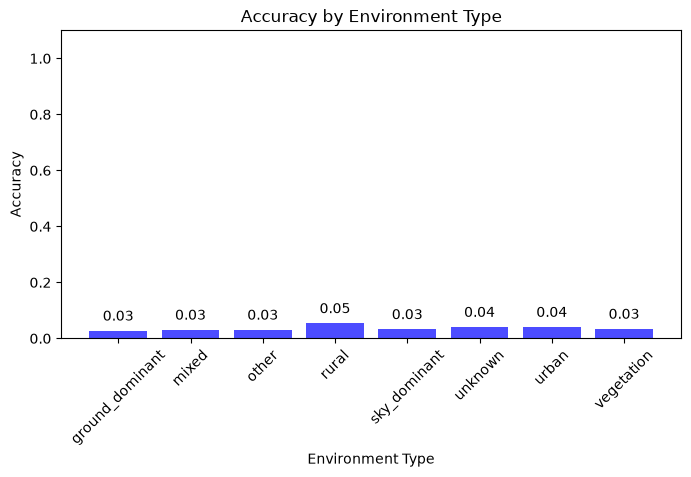

In [7]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='accuracy', title='Accuracy by Environment Type', ylabel='Accuracy', xlabel='Environment Type')

### Precision

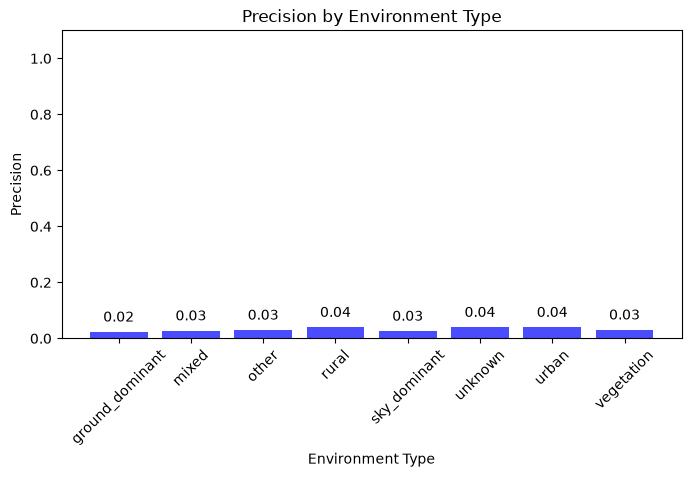

In [8]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='precision', title='Precision by Environment Type', ylabel='Precision', xlabel='Environment Type')

### Recall

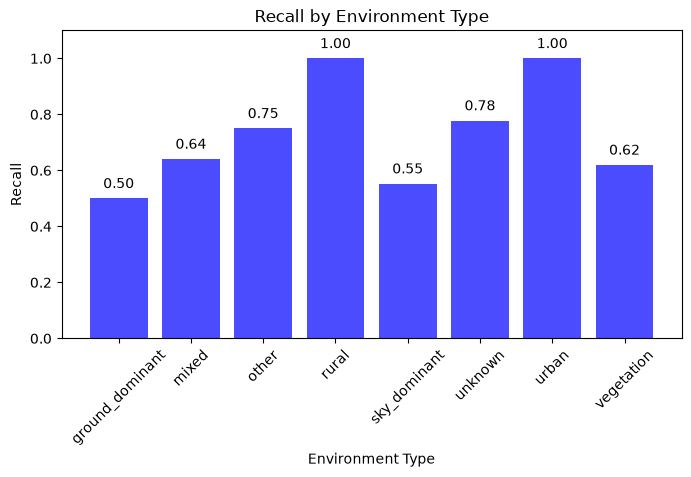

In [9]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='recall', title='Recall by Environment Type', ylabel='Recall', xlabel='Environment Type')

### Hit Rate

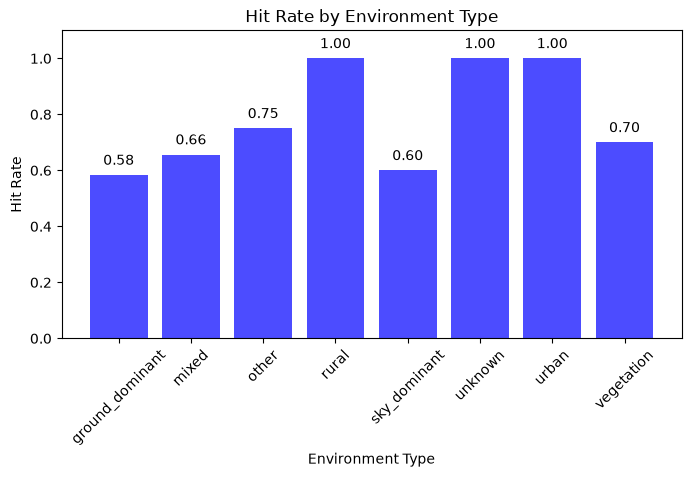

In [10]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='hit_rate', title='Hit Rate by Environment Type', ylabel='Hit Rate', xlabel='Environment Type')

### Diversity


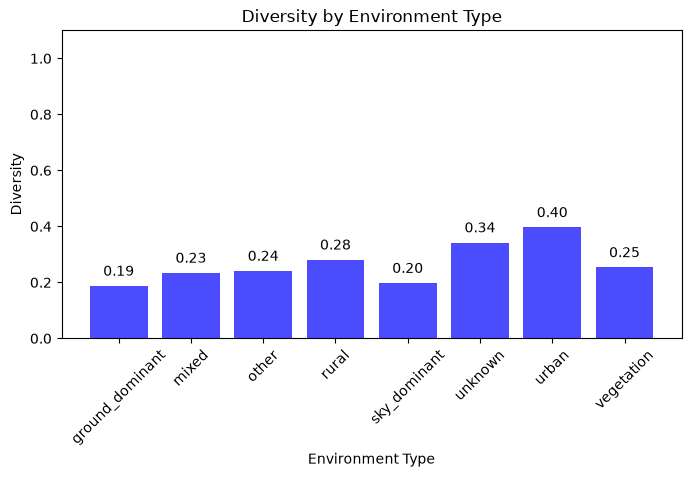

In [11]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='diversity', title='Diversity by Environment Type', ylabel='Diversity', xlabel='Environment Type')

### NDCG

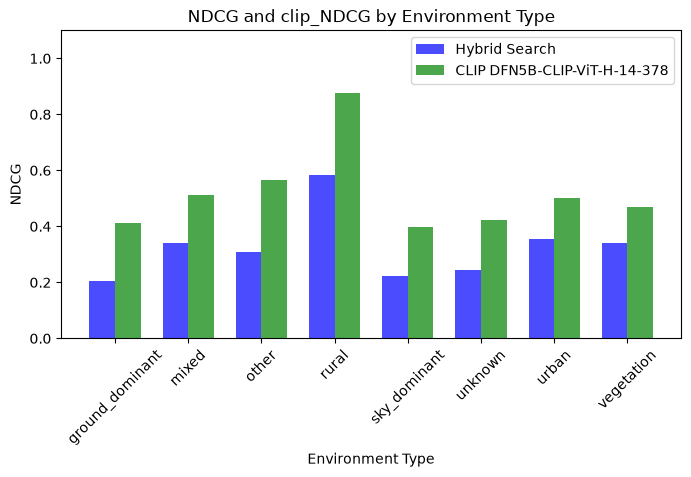

In [12]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='NDCG and clip_NDCG by Environment Type', xlabel='Environment Type')

### MRR

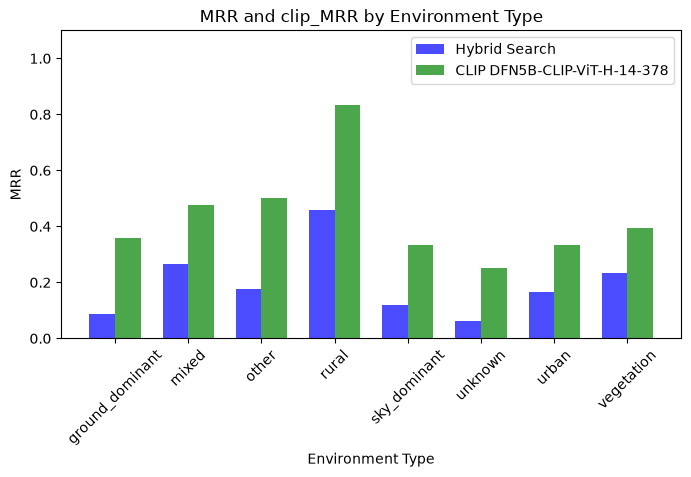

In [13]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='MRR and clip_MRR by Environment Type', xlabel='Environment Type', metric="MRR")

## Metrics based on Lighting

In [14]:


# Group by iconic_group and calculate the sum/mean of each metric
lighting_metrics = df.groupby(['lighting']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
lighting_metrics = lighting_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

lighting_metrics

,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,day,1625,53,1572,46,1579,0.032615,0.028308,0.612821,0.646154,0.297571,0.480832,0.203859,0.427949,0.216720
1,dusk,75,2,73,1,74,0.026667,0.013333,0.166667,0.333333,0.118736,0.210310,0.055556,0.166667,0.153425
2,night,1025,32,993,29,996,0.031220,0.028293,0.638211,0.707317,0.280314,0.430291,0.167430,0.344386,0.250202
3,overcast_light,225,8,217,8,217,0.035556,0.035556,0.694444,0.777778,0.414127,0.615310,0.284303,0.574074,0.242208
4,unknown,50,1,49,1,49,0.020000,0.020000,0.500000,0.500000,0.232669,0.500000,0.166667,0.500000,0.230137


In [15]:
# Bar width
bar_width = 0.35
x = np.arange(len(lighting_metrics['lighting']))

### Accuracy

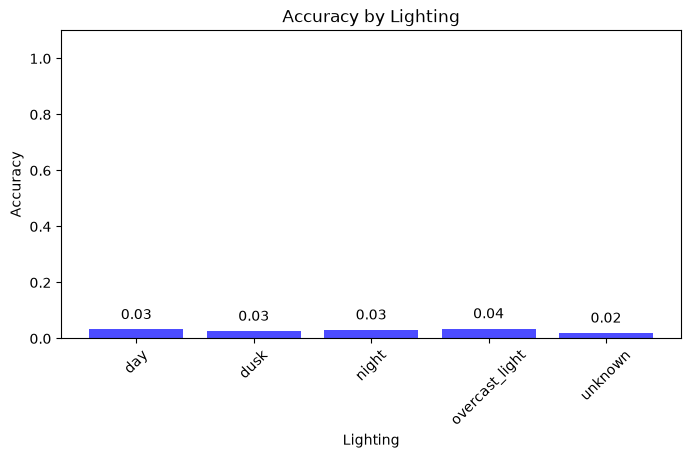

In [16]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='accuracy', title='Accuracy by Lighting', ylabel='Accuracy', xlabel='Lighting')

### Precision

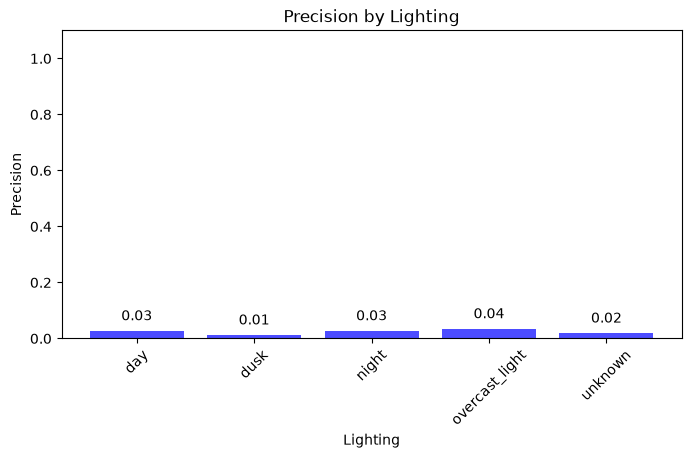

In [17]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='precision', title='Precision by Lighting', ylabel='Precision', xlabel='Lighting')

### Recall

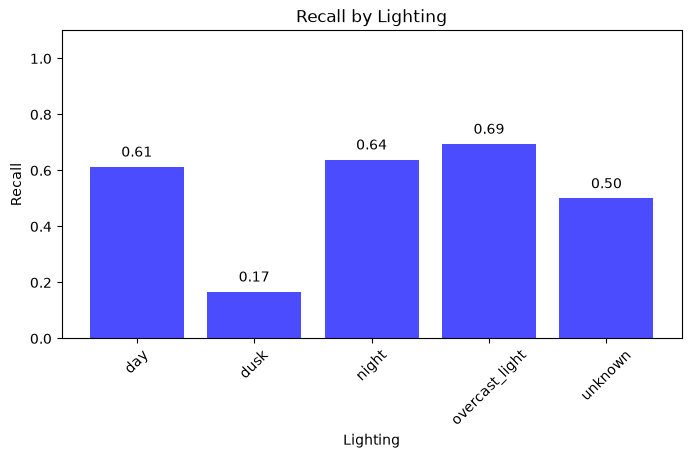

In [18]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='recall', title='Recall by Lighting', ylabel='Recall', xlabel='Lighting')

### Hit Rate

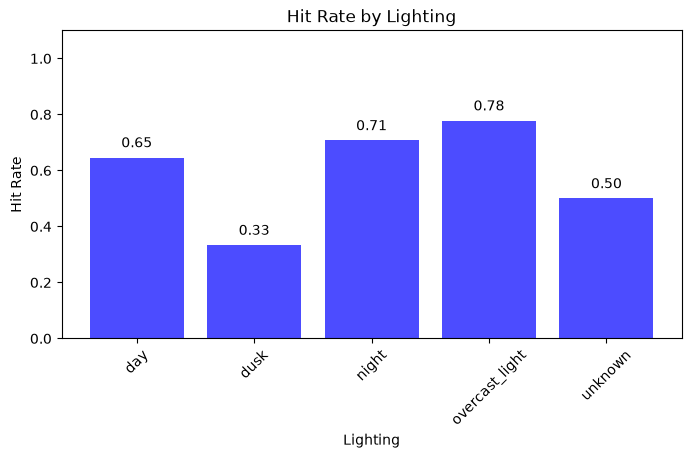

In [19]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='hit_rate', title='Hit Rate by Lighting', ylabel='Hit Rate', xlabel='Lighting')

### Diversity

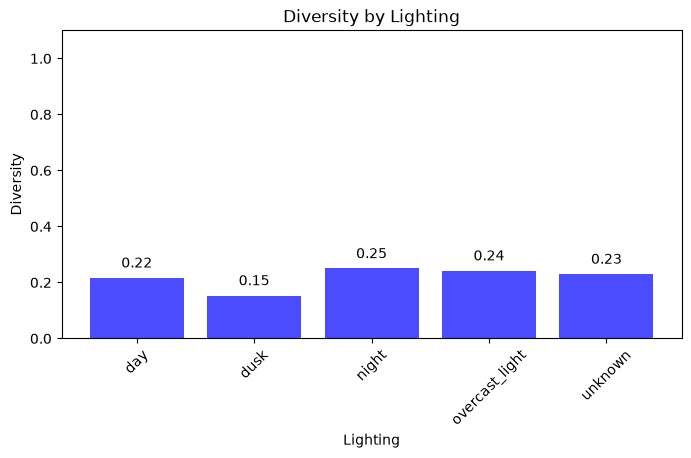

In [20]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='diversity', title='Diversity by Lighting', ylabel='Diversity', xlabel='Lighting')

### NDCG

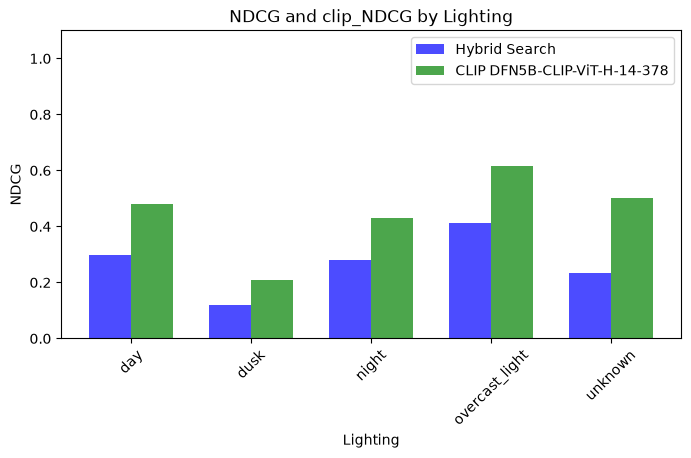

In [21]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='NDCG and clip_NDCG by Lighting', xlabel='Lighting')

### MRR

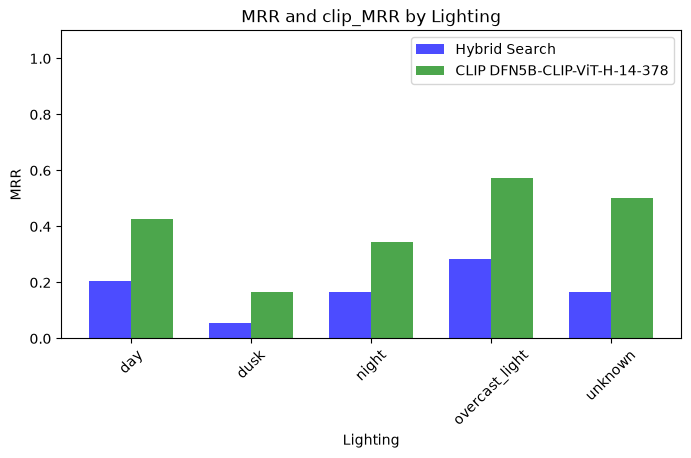

In [22]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='MRR and clip_MRR by Lighting', xlabel='Lighting', metric="MRR")

## Metrics based on Viewpoint

In [23]:
# Group by viewpoint and calculate the sum/mean of each metric
viewpoint_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
viewpoint_metrics = viewpoint_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

viewpoint_metrics

,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,duo_view,50,1,49,1,49,0.020000,0.020000,0.500000,0.500000,0.150515,0.250000,0.055556,0.166667,0.198443
1,fisheye_sky,700,24,676,20,680,0.034286,0.028571,0.583333,0.642857,0.225248,0.424036,0.110379,0.350170,0.177799
2,ground_horizontal,1925,62,1863,55,1870,0.032208,0.028571,0.633117,0.675325,0.316883,0.488642,0.218230,0.432035,0.243067
3,ground_upward,150,4,146,4,146,0.026667,0.026667,0.666667,0.666667,0.354663,0.488660,0.272398,0.435185,0.264884
4,oblique,125,3,122,3,122,0.024000,0.024000,0.466667,0.600000,0.357813,0.500000,0.286667,0.466667,0.222254
5,unknown,50,2,48,2,48,0.040000,0.040000,0.666667,1.000000,0.229338,0.317182,0.050505,0.126984,0.326765


### Accuracy

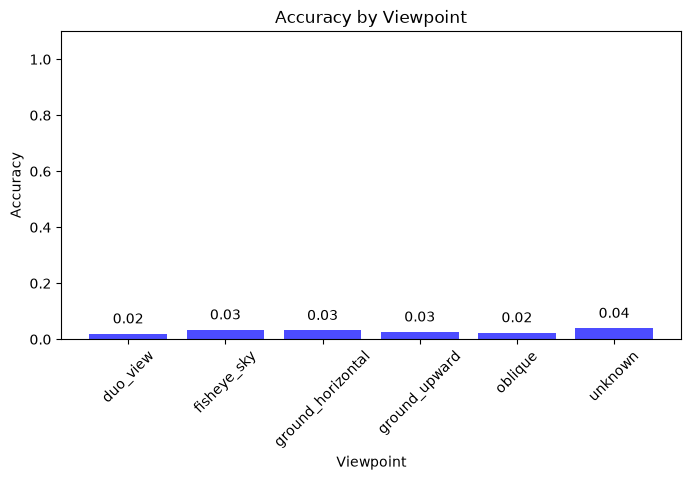

In [24]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='accuracy', title='Accuracy by Viewpoint', ylabel='Accuracy', xlabel='Viewpoint')

### Precision

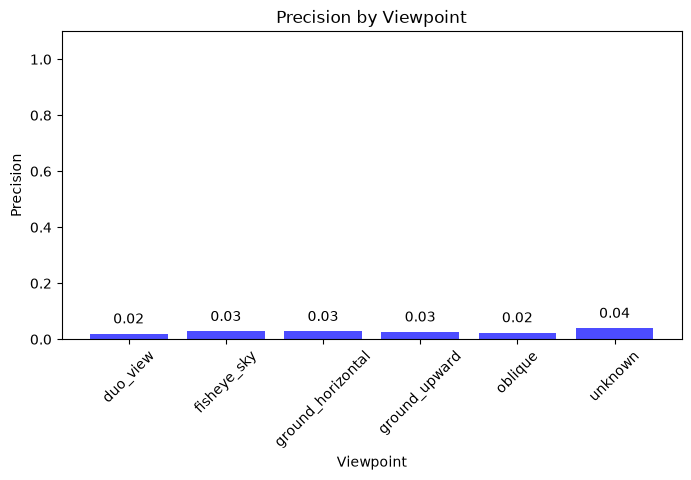

In [25]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='precision', title='Precision by Viewpoint', ylabel='Precision', xlabel='Viewpoint')

### Recall

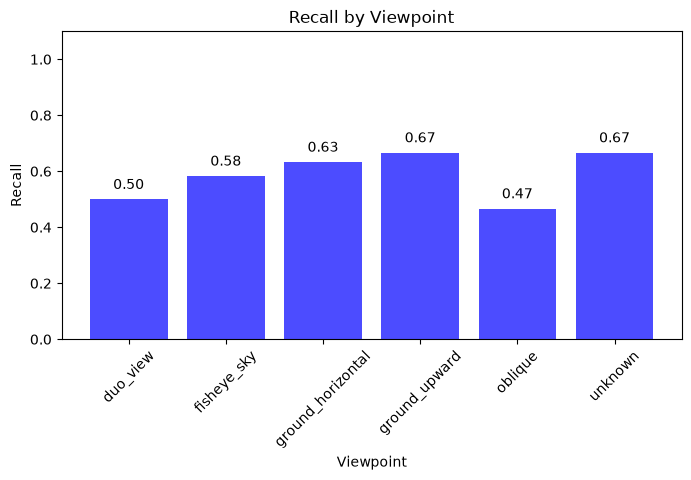

In [26]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='recall', title='Recall by Viewpoint', ylabel='Recall', xlabel='Viewpoint')

### Hit Rate

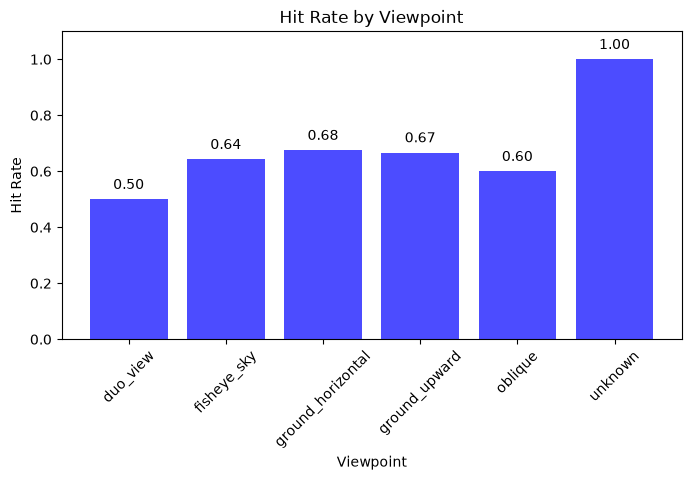

In [27]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='hit_rate', title='Hit Rate by Viewpoint', ylabel='Hit Rate', xlabel='Viewpoint')

### Diversity

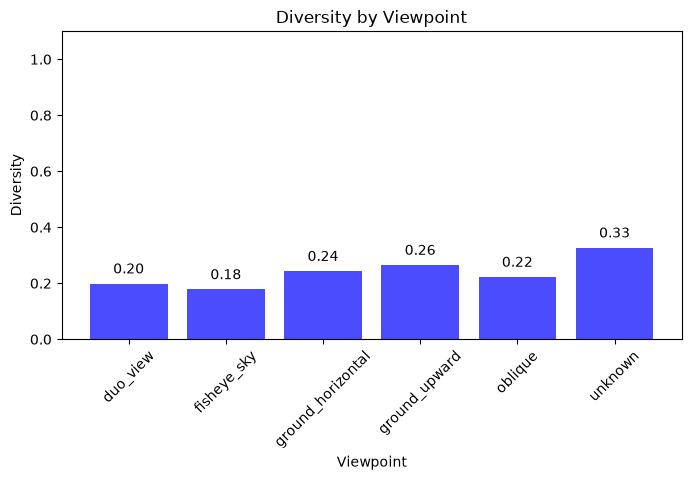

In [28]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='diversity', title='Diversity by Viewpoint', ylabel='Diversity', xlabel='Viewpoint')

### NDCG

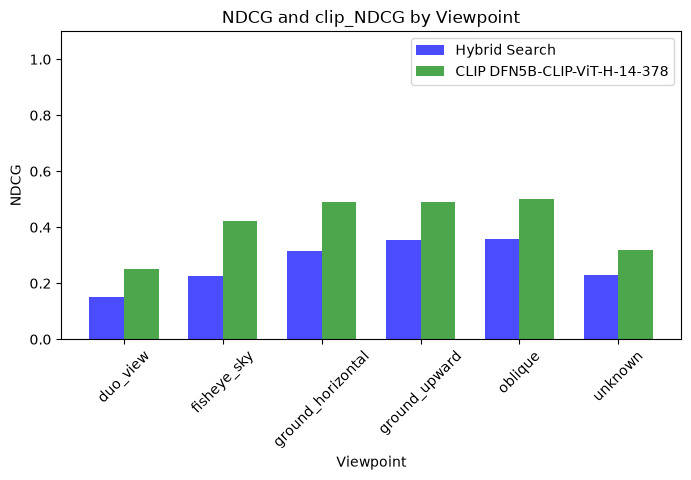

In [29]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='NDCG and clip_NDCG by Viewpoint', xlabel='Viewpoint')

### MRR

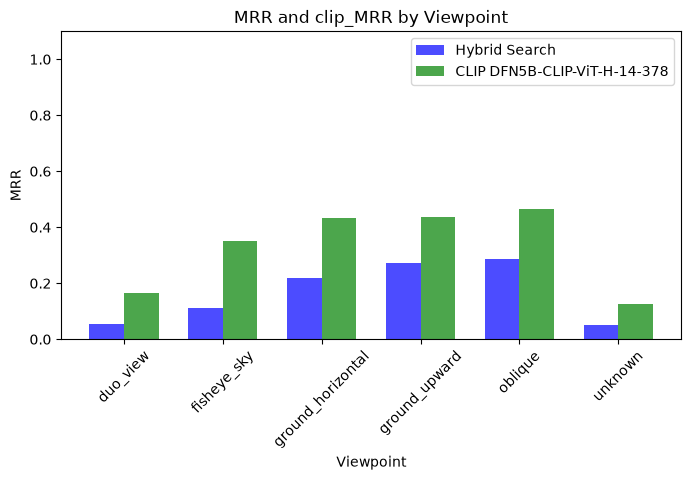

In [30]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='MRR and clip_MRR by Viewpoint', xlabel='Viewpoint', metric="MRR")

## Metrics based on Sky Condition

Now, we will evaluate queries based on sky condition.


In [31]:
# Group by sky_condition and calculate the sum/mean of each metric
sky_condition_metrics = df.groupby('sky_condition').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
sky_condition_metrics = sky_condition_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

sky_condition_metrics


,sky_condition,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,clear,1000,31,969,27,973,0.031000,0.027000,0.579167,0.650000,0.330842,0.428212,0.237838,0.355536,0.243942
1,fog_or_haze,225,3,222,2,223,0.013333,0.008889,0.222222,0.222222,0.116764,0.181214,0.117284,0.166667,0.182217
2,other,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.630930,0.630930,0.500000,0.500000,0.337636
3,overcast,500,19,481,17,483,0.038000,0.034000,0.712500,0.750000,0.363212,0.580859,0.254246,0.530833,0.240277
4,partly_cloudy,700,24,676,21,679,0.034286,0.030000,0.642857,0.678571,0.284506,0.530814,0.172007,0.489286,0.193757
5,unknown,550,18,532,17,533,0.032727,0.030909,0.696970,0.772727,0.238082,0.463384,0.100181,0.366595,0.249070


### Accuracy


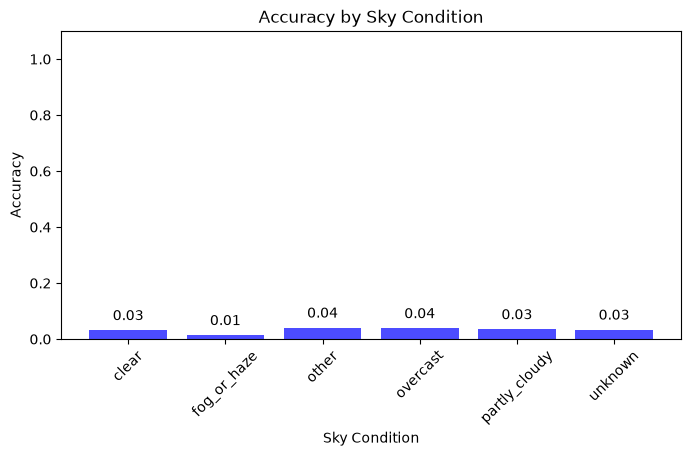

In [32]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='accuracy', title='Accuracy by Sky Condition', ylabel='Accuracy', xlabel='Sky Condition')


### Precision


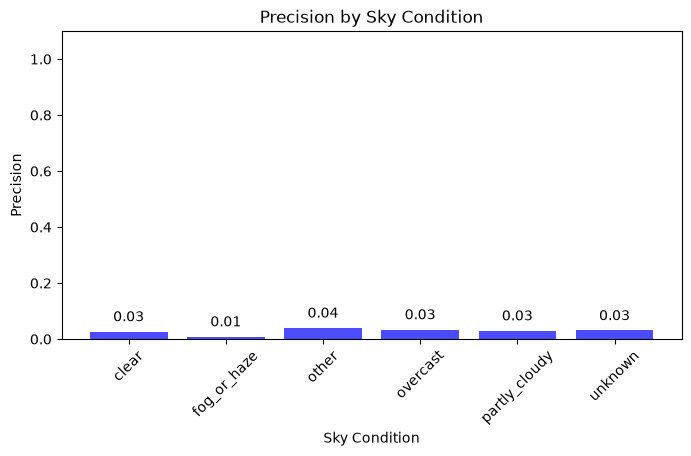

In [33]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='precision', title='Precision by Sky Condition', ylabel='Precision', xlabel='Sky Condition')


### Recall


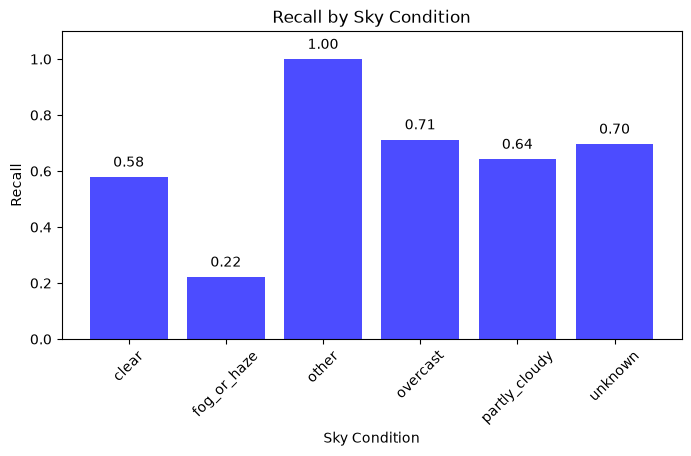

In [34]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='recall', title='Recall by Sky Condition', ylabel='Recall', xlabel='Sky Condition')


### Hit Rate


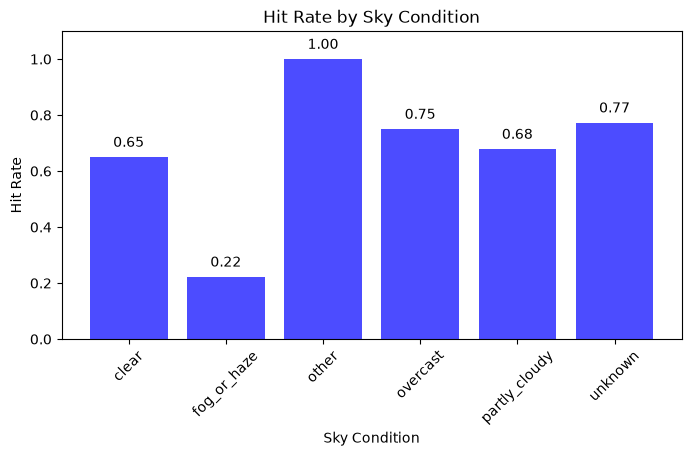

In [35]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='hit_rate', title='Hit Rate by Sky Condition', ylabel='Hit Rate', xlabel='Sky Condition')


### Diversity


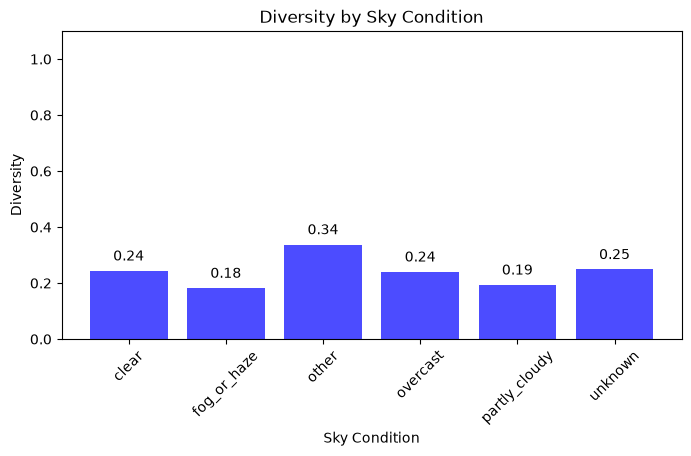

In [36]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='diversity', title='Diversity by Sky Condition', ylabel='Diversity', xlabel='Sky Condition')


### NDCG


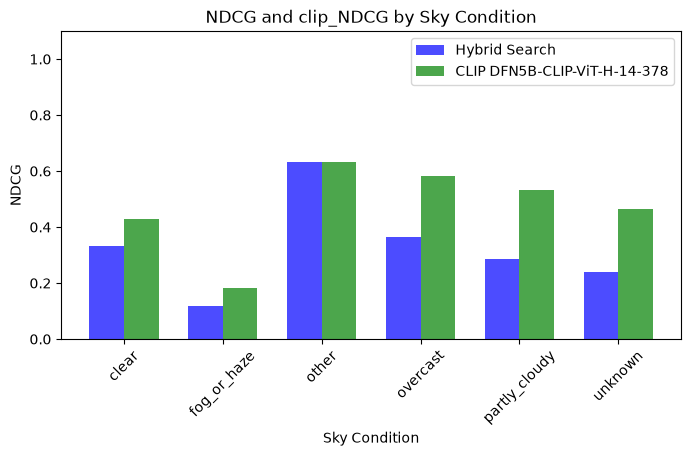

In [37]:
plot_rank_comparison(sky_condition_metrics, x_column='sky_condition', title='NDCG and clip_NDCG by Sky Condition', xlabel='Sky Condition')


### MRR


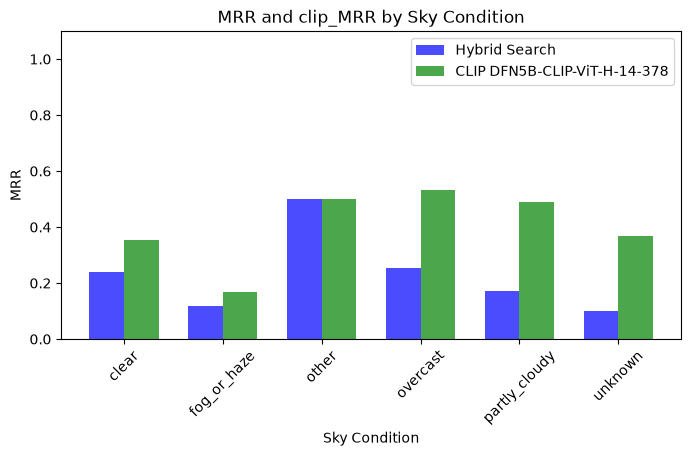

In [38]:
plot_rank_comparison(sky_condition_metrics, x_column='sky_condition', title='MRR and clip_MRR by Sky Condition', xlabel='Sky Condition', metric="MRR")


## Metrics based on Horizon Present

Now, we will evaluate queries based on **Horizon Present** (true vs false).


In [39]:
# Group by horizon_present and calculate the sum/mean of each metric
horizon_present_metrics = df.groupby('horizon_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
horizon_present_metrics['horizon_present'] = horizon_present_metrics['horizon_present'].map({True: 'True', False: 'False'})

#rename columns
horizon_present_metrics = horizon_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
horizon_present_metrics = horizon_present_metrics.sort_values('horizon_present')

horizon_present_metrics


,horizon_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,850,26,824,23,827,0.030588,0.027059,0.627451,0.676471,0.275187,0.454210,0.159528,0.383777,0.240930
1,True,2150,70,2080,62,2088,0.032558,0.028837,0.609496,0.662791,0.302643,0.472344,0.206398,0.413427,0.223883


### Accuracy


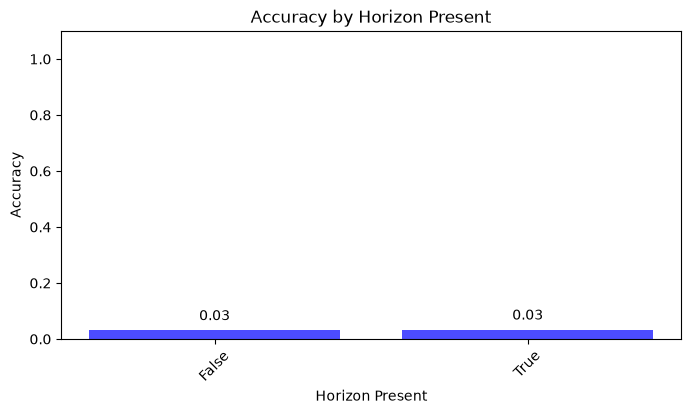

In [40]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='accuracy', title='Accuracy by Horizon Present', ylabel='Accuracy', xlabel='Horizon Present')


### Precision


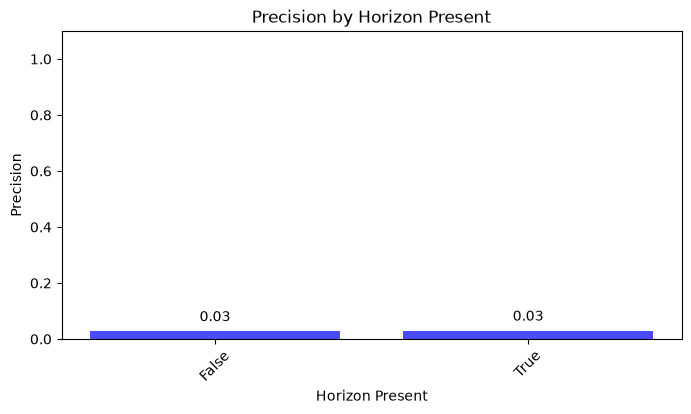

In [41]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='precision', title='Precision by Horizon Present', ylabel='Precision', xlabel='Horizon Present')


### Recall


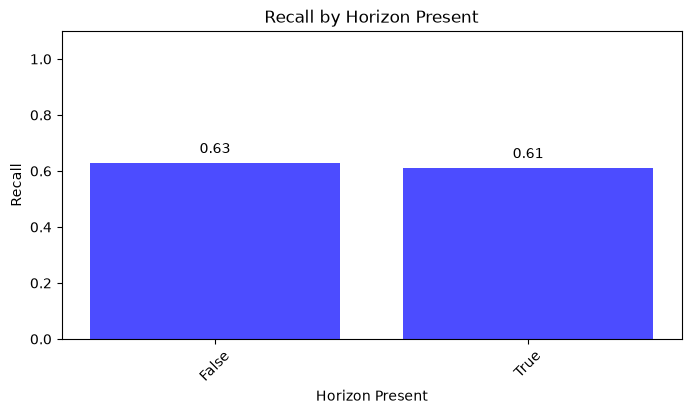

In [42]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='recall', title='Recall by Horizon Present', ylabel='Recall', xlabel='Horizon Present')


### Hit Rate


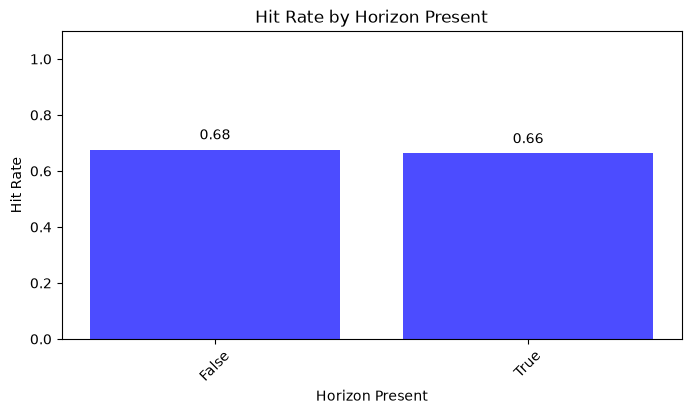

In [43]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='hit_rate', title='Hit Rate by Horizon Present', ylabel='Hit Rate', xlabel='Horizon Present')


### Diversity


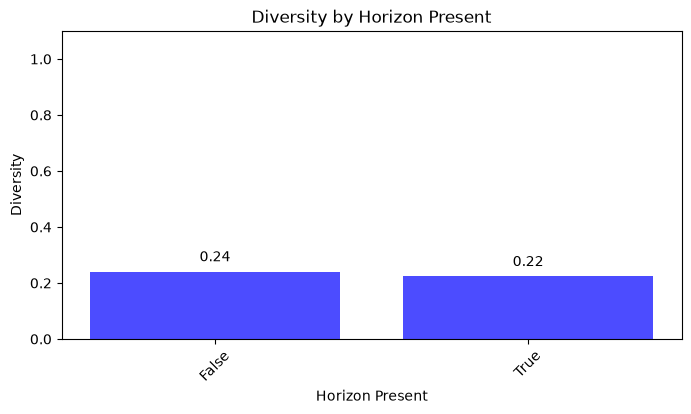

In [44]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='diversity', title='Diversity by Horizon Present', ylabel='Diversity', xlabel='Horizon Present')


### NDCG


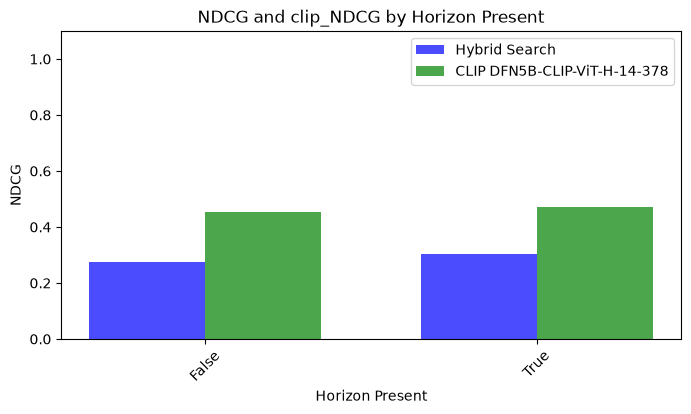

In [45]:
plot_rank_comparison(horizon_present_metrics, x_column='horizon_present', title='NDCG and clip_NDCG by Horizon Present', xlabel='Horizon Present')


### MRR


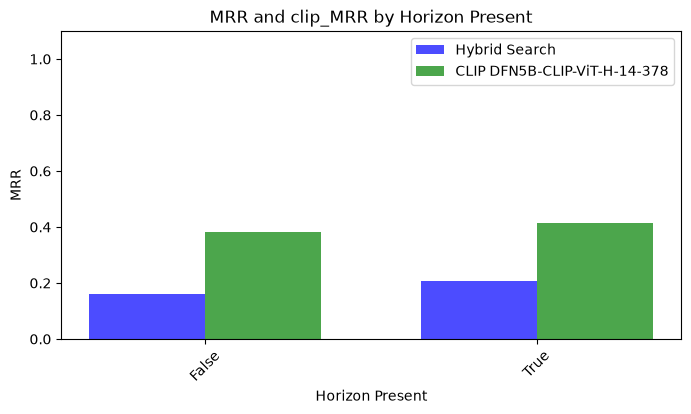

In [46]:
plot_rank_comparison(horizon_present_metrics, x_column='horizon_present', title='MRR and clip_MRR by Horizon Present', xlabel='Horizon Present', metric="MRR")


## Metrics based on Ground Present

Now, we will evaluate queries based on **Ground Present** (true vs false).


In [47]:
# Group by ground_present and calculate the sum/mean of each metric
ground_present_metrics = df.groupby('ground_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
ground_present_metrics['ground_present'] = ground_present_metrics['ground_present'].map({True: 'True', False: 'False'})


#rename columns
ground_present_metrics = ground_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
ground_present_metrics = ground_present_metrics.sort_values('ground_present')

ground_present_metrics


,ground_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,475,16,459,14,461,0.033684,0.029474,0.649123,0.684211,0.297544,0.446152,0.198647,0.371846,0.253134
1,True,2525,80,2445,71,2454,0.031683,0.028119,0.608086,0.663366,0.294360,0.471167,0.192078,0.411268,0.224119


### Accuracy


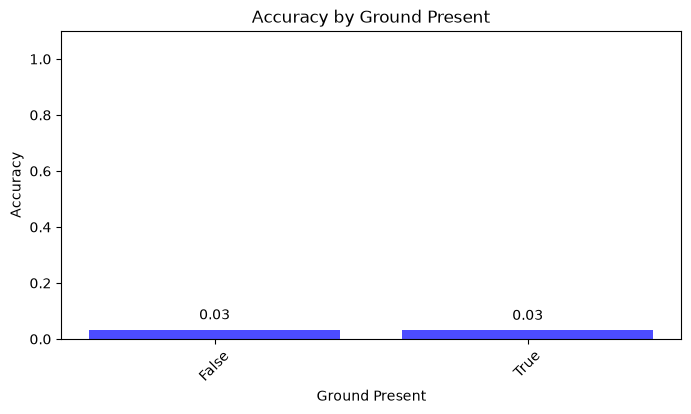

In [48]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='accuracy', title='Accuracy by Ground Present', ylabel='Accuracy', xlabel='Ground Present')


### Precision


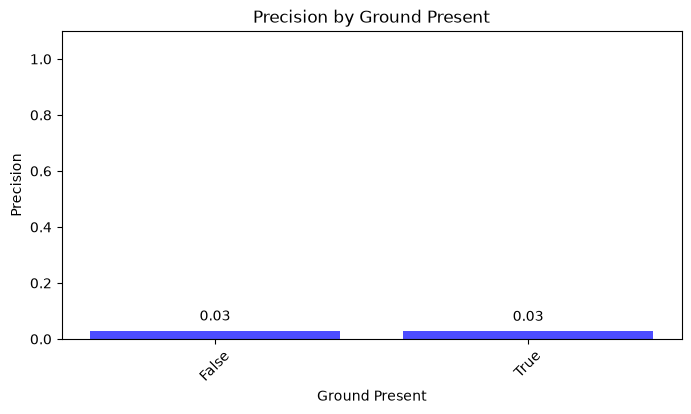

In [49]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='precision', title='Precision by Ground Present', ylabel='Precision', xlabel='Ground Present')


### Recall


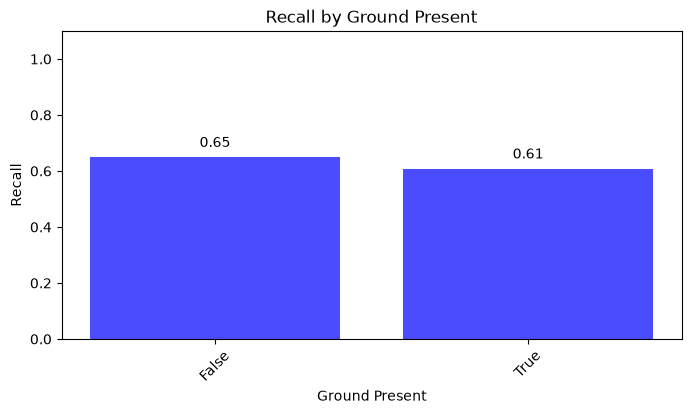

In [50]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='recall', title='Recall by Ground Present', ylabel='Recall', xlabel='Ground Present')


### Hit Rate


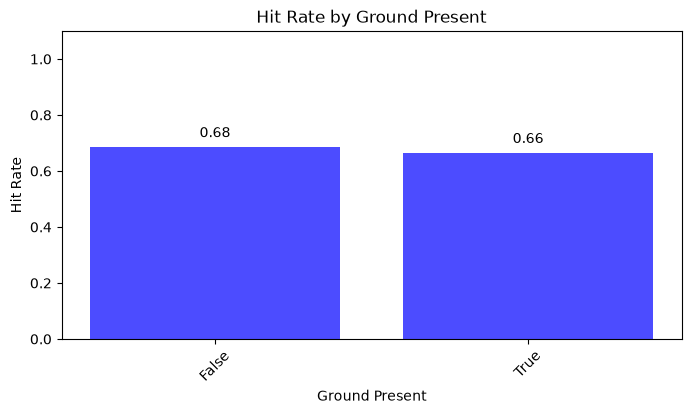

In [51]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='hit_rate', title='Hit Rate by Ground Present', ylabel='Hit Rate', xlabel='Ground Present')


### Diversity


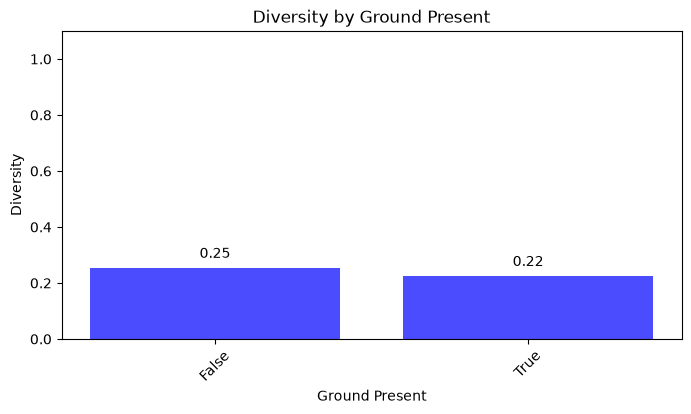

In [52]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='diversity', title='Diversity by Ground Present', ylabel='Diversity', xlabel='Ground Present')


### NDCG


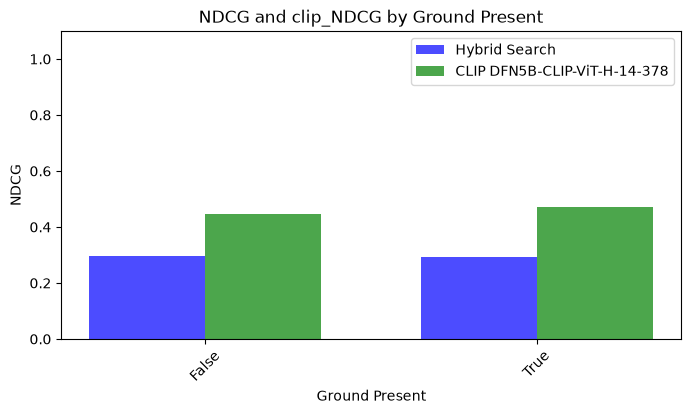

In [53]:
plot_rank_comparison(ground_present_metrics, x_column='ground_present', title='NDCG and clip_NDCG by Ground Present', xlabel='Ground Present')


### MRR


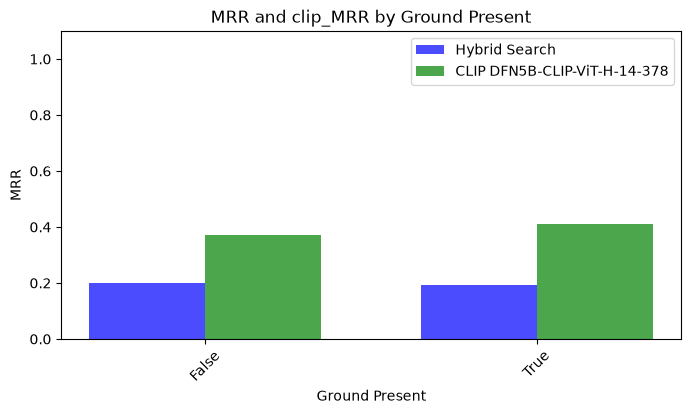

In [54]:
plot_rank_comparison(ground_present_metrics, x_column='ground_present', title='MRR and clip_MRR by Ground Present', xlabel='Ground Present', metric="MRR")


## Metrics based on Sky Dominates

Now, we will evaluate queries based on **Sky Dominates** (true vs false).


In [55]:
# Group by sky_dominates and calculate the sum/mean of each metric
sky_dominates_metrics = df.groupby('sky_dominates').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

sky_dominates_metrics['sky_dominates'] = sky_dominates_metrics['sky_dominates'].map({True: 'True', False: 'False'})

#rename columns
sky_dominates_metrics = sky_dominates_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
sky_dominates_metrics = sky_dominates_metrics.sort_values('sky_dominates')

sky_dominates_metrics


,sky_dominates,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1800,58,1742,52,1748,0.032222,0.028889,0.616898,0.680556,0.318143,0.484453,0.217823,0.425750,0.239134
1,True,1200,38,1162,33,1167,0.031667,0.027500,0.611111,0.645833,0.259946,0.441336,0.156061,0.373942,0.213081


### Accuracy


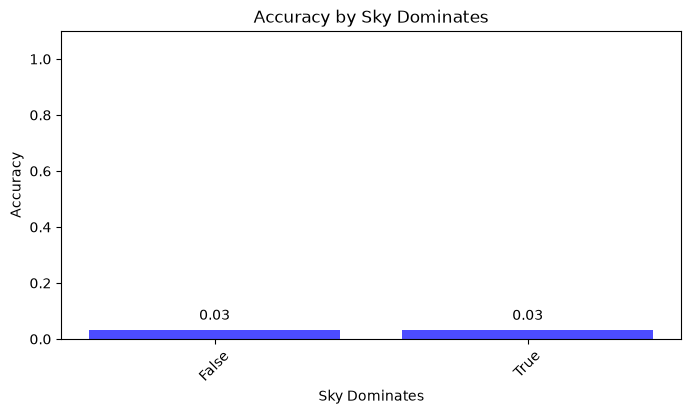

In [56]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='accuracy', title='Accuracy by Sky Dominates', ylabel='Accuracy', xlabel='Sky Dominates')


### Precision


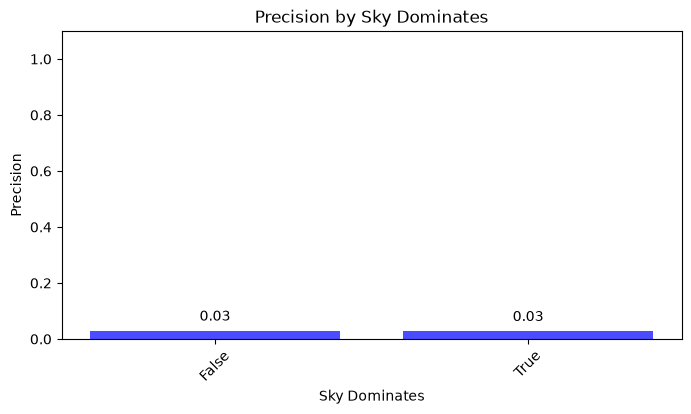

In [57]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='precision', title='Precision by Sky Dominates', ylabel='Precision', xlabel='Sky Dominates')


### Recall


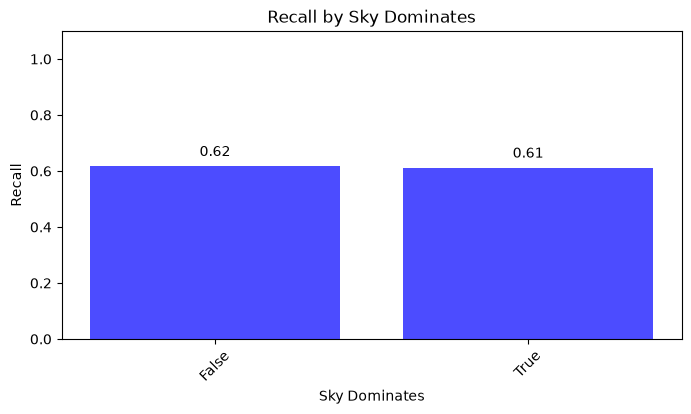

In [58]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='recall', title='Recall by Sky Dominates', ylabel='Recall', xlabel='Sky Dominates')


### Hit Rate


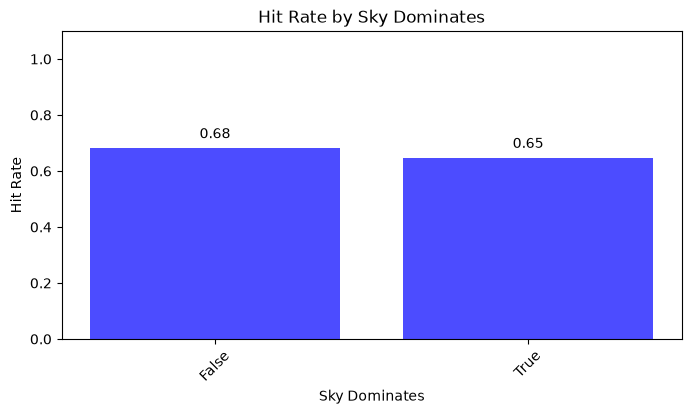

In [59]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='hit_rate', title='Hit Rate by Sky Dominates', ylabel='Hit Rate', xlabel='Sky Dominates')


### Diversity


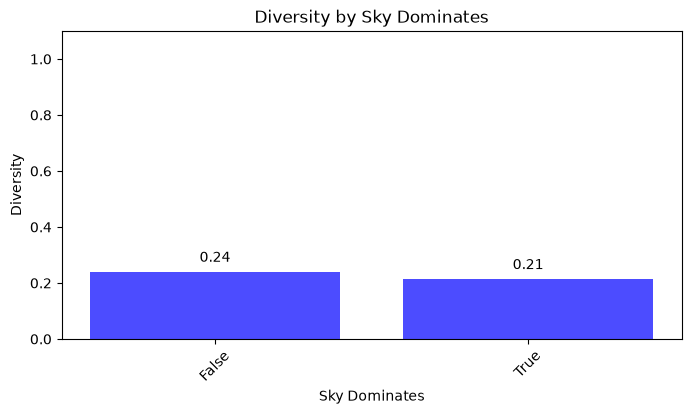

In [60]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='diversity', title='Diversity by Sky Dominates', ylabel='Diversity', xlabel='Sky Dominates')


### NDCG


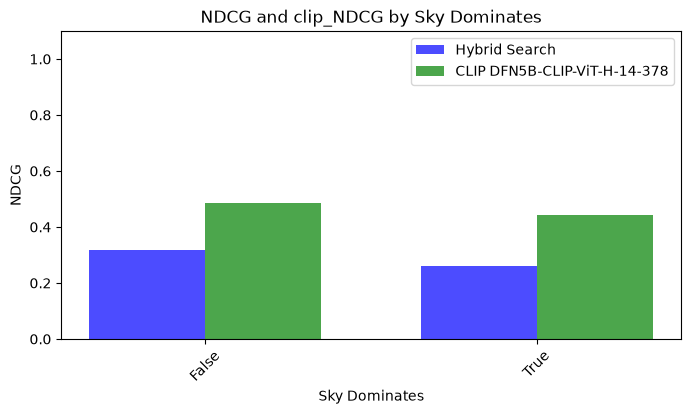

In [61]:
plot_rank_comparison(sky_dominates_metrics, x_column='sky_dominates', title='NDCG and clip_NDCG by Sky Dominates', xlabel='Sky Dominates')


### MRR


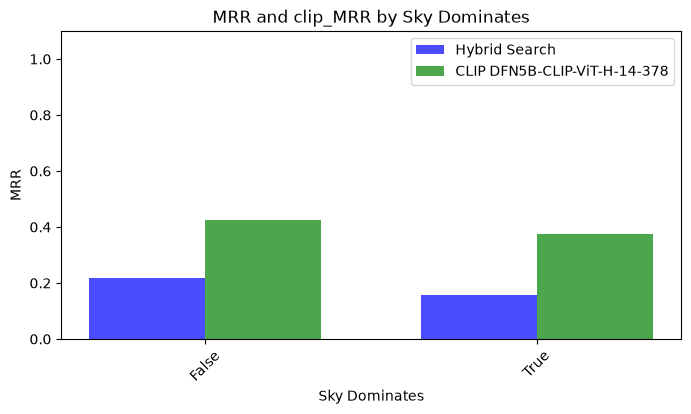

In [62]:
plot_rank_comparison(sky_dominates_metrics, x_column='sky_dominates', title='MRR and clip_MRR by Sky Dominates', xlabel='Sky Dominates', metric="MRR")


## Metrics based on Vegetation Present

Now, we will evaluate queries based on **Vegetation Present** (true vs false).


In [63]:
# Group by vegetation_present and calculate the sum/mean of each metric
vegetation_present_metrics = df.groupby('vegetation_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

vegetation_present_metrics['vegetation_present'] = vegetation_present_metrics['vegetation_present'].map({True: 'True', False: 'False'})


#rename columns
vegetation_present_metrics = vegetation_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
vegetation_present_metrics = vegetation_present_metrics.sort_values('vegetation_present')

vegetation_present_metrics


,vegetation_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1125,33,1092,30,1095,0.029333,0.026667,0.570370,0.622222,0.229106,0.398481,0.119867,0.325996,0.205990
1,True,1875,63,1812,55,1820,0.033600,0.029333,0.641111,0.693333,0.334319,0.508442,0.237069,0.452444,0.242346


### Accuracy


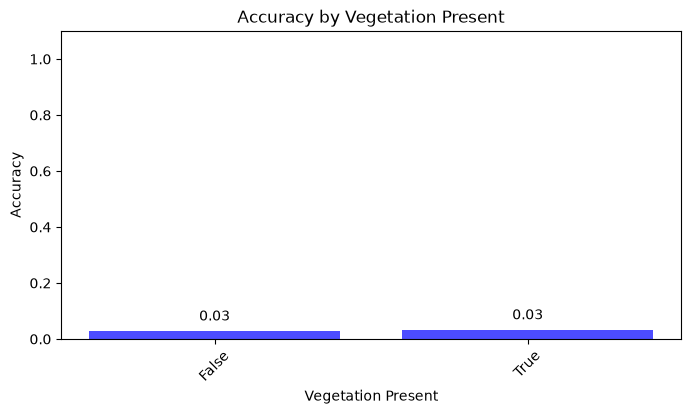

In [64]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='accuracy', title='Accuracy by Vegetation Present', ylabel='Accuracy', xlabel='Vegetation Present')


### Precision


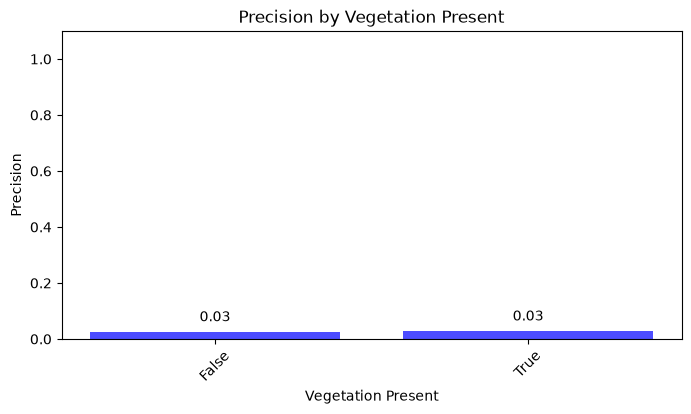

In [65]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='precision', title='Precision by Vegetation Present', ylabel='Precision', xlabel='Vegetation Present')


### Recall


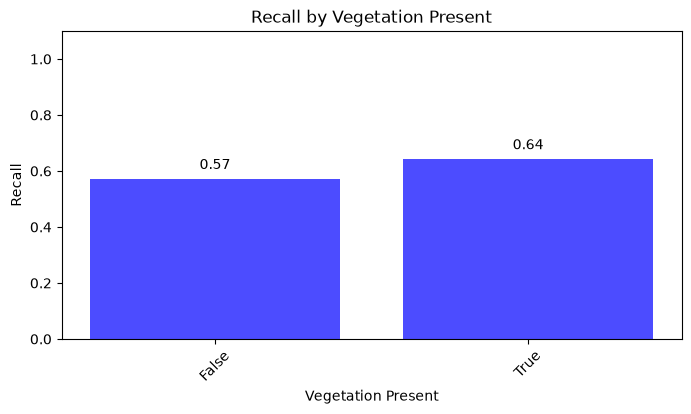

In [66]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='recall', title='Recall by Vegetation Present', ylabel='Recall', xlabel='Vegetation Present')


### Hit Rate


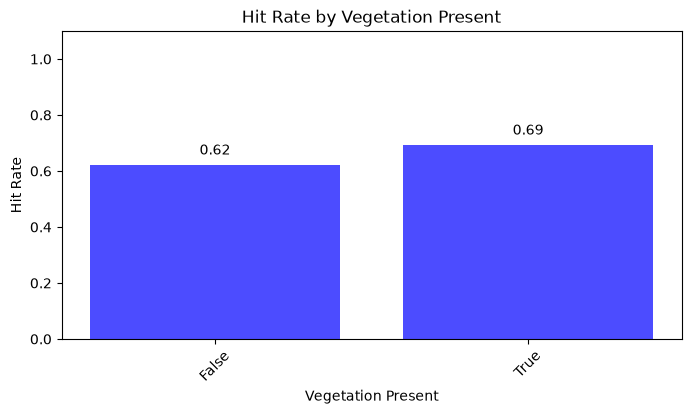

In [67]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='hit_rate', title='Hit Rate by Vegetation Present', ylabel='Hit Rate', xlabel='Vegetation Present')


### Diversity


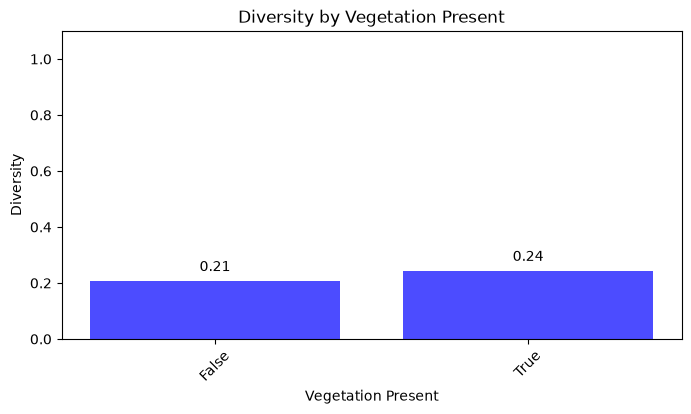

In [68]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='diversity', title='Diversity by Vegetation Present', ylabel='Diversity', xlabel='Vegetation Present')


### NDCG


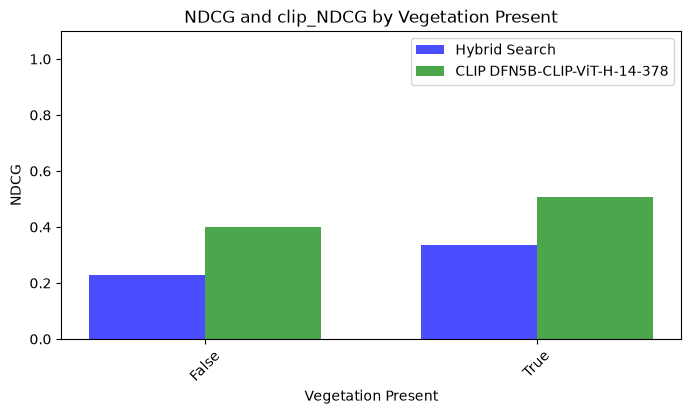

In [69]:
plot_rank_comparison(vegetation_present_metrics, x_column='vegetation_present', title='NDCG and clip_NDCG by Vegetation Present', xlabel='Vegetation Present')


### MRR


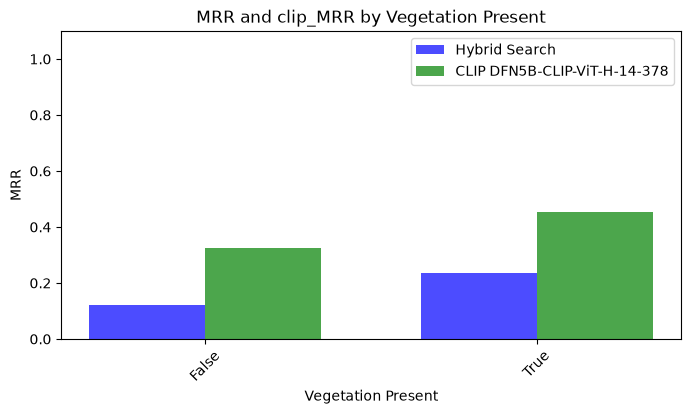

In [70]:
plot_rank_comparison(vegetation_present_metrics, x_column='vegetation_present', title='MRR and clip_MRR by Vegetation Present', xlabel='Vegetation Present', metric="MRR")


## Metrics based on Water Present

Now, we will evaluate queries based on **Water Present** (true vs false).


In [71]:
# Group by water_present and calculate the sum/mean of each metric
water_present_metrics = df.groupby('water_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

water_present_metrics['water_present'] = water_present_metrics['water_present'].map({True: 'True', False: 'False'})

#rename columns
water_present_metrics = water_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
water_present_metrics = water_present_metrics.sort_values('water_present')

water_present_metrics


,water_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2825,88,2737,78,2747,0.031150,0.027611,0.590708,0.646018,0.274535,0.446930,0.172905,0.385131,0.220868
1,True,175,8,167,7,168,0.045714,0.040000,1.000000,1.000000,0.623034,0.794515,0.519424,0.726190,0.355348


### Accuracy


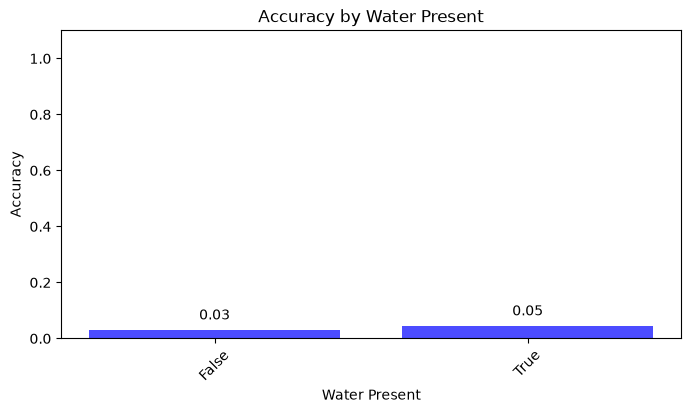

In [72]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='accuracy', title='Accuracy by Water Present', ylabel='Accuracy', xlabel='Water Present')


### Precision


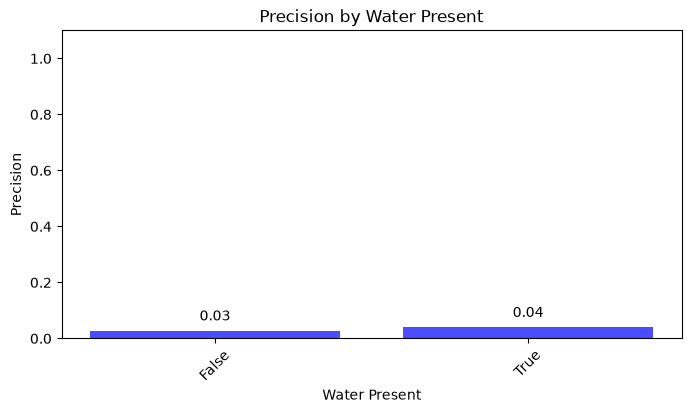

In [73]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='precision', title='Precision by Water Present', ylabel='Precision', xlabel='Water Present')


### Recall


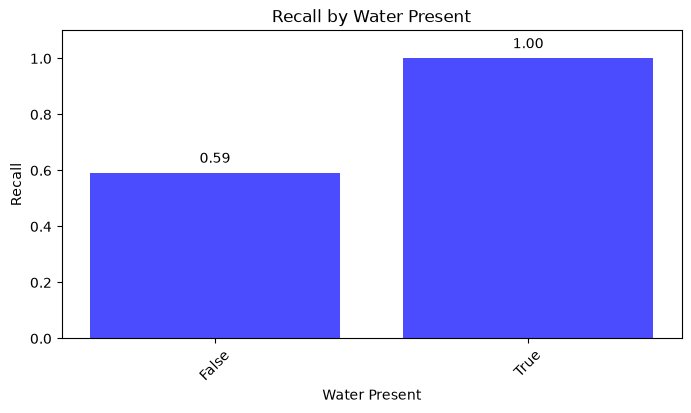

In [74]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='recall', title='Recall by Water Present', ylabel='Recall', xlabel='Water Present')


### Hit Rate


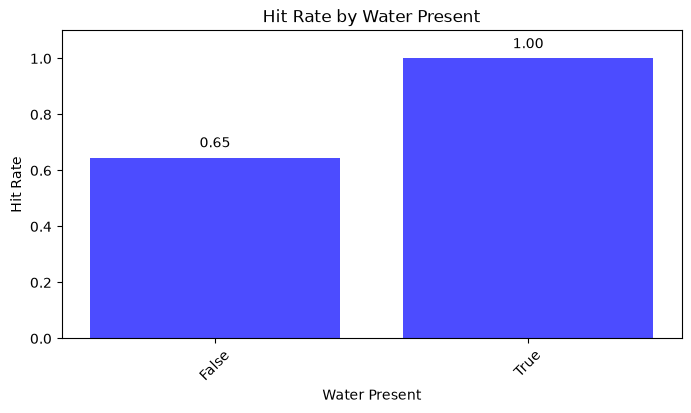

In [75]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='hit_rate', title='Hit Rate by Water Present', ylabel='Hit Rate', xlabel='Water Present')


### Diversity


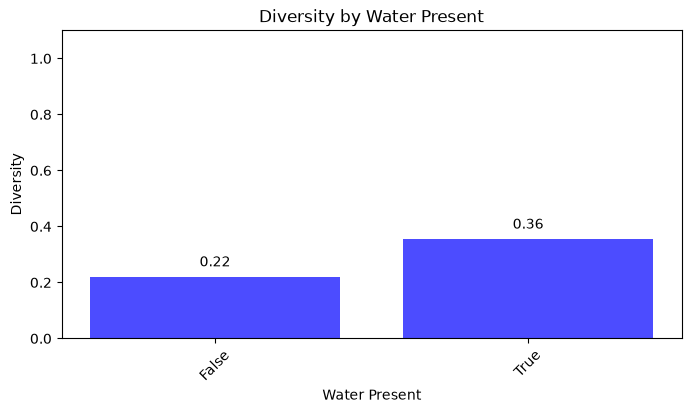

In [76]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='diversity', title='Diversity by Water Present', ylabel='Diversity', xlabel='Water Present')


### NDCG


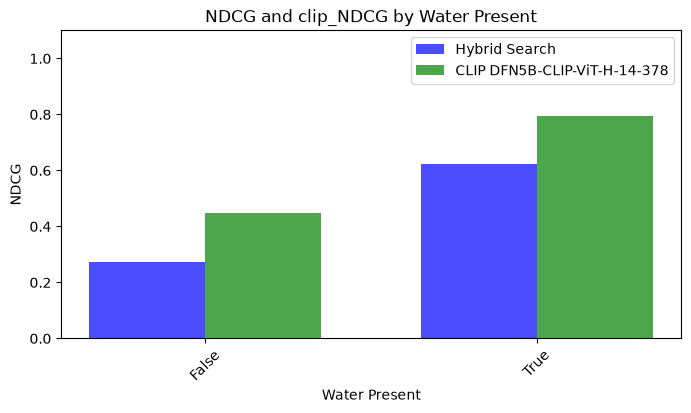

In [77]:
plot_rank_comparison(water_present_metrics, x_column='water_present', title='NDCG and clip_NDCG by Water Present', xlabel='Water Present')


### MRR


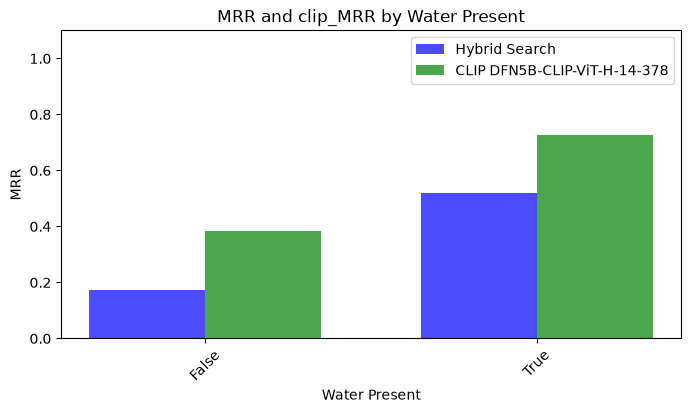

In [78]:
plot_rank_comparison(water_present_metrics, x_column='water_present', title='MRR and clip_MRR by Water Present', xlabel='Water Present', metric="MRR")


## Metrics based on Buildings Present

Now, we will evaluate queries based on **Buildings Present** (true vs false).


In [79]:
# Group by buildings_present and calculate the sum/mean of each metric
buildings_present_metrics = df.groupby('buildings_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

buildings_present_metrics['buildings_present'] = buildings_present_metrics['buildings_present'].map({True: 'True', False: 'False'})

#rename columns
buildings_present_metrics = buildings_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
buildings_present_metrics = buildings_present_metrics.sort_values('buildings_present')

buildings_present_metrics


,buildings_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1950,64,1886,57,1893,0.032821,0.029231,0.612179,0.666667,0.290648,0.468447,0.192514,0.408588,0.236391
1,True,1050,32,1018,28,1022,0.030476,0.026667,0.619048,0.666667,0.302694,0.464901,0.194241,0.398413,0.214453


### Accuracy


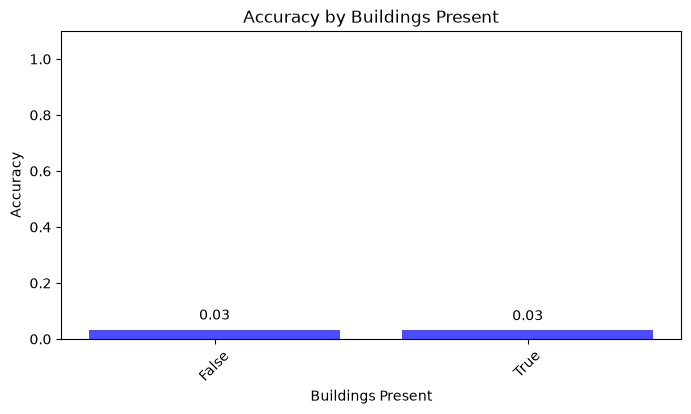

In [80]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='accuracy', title='Accuracy by Buildings Present', ylabel='Accuracy', xlabel='Buildings Present')


### Precision


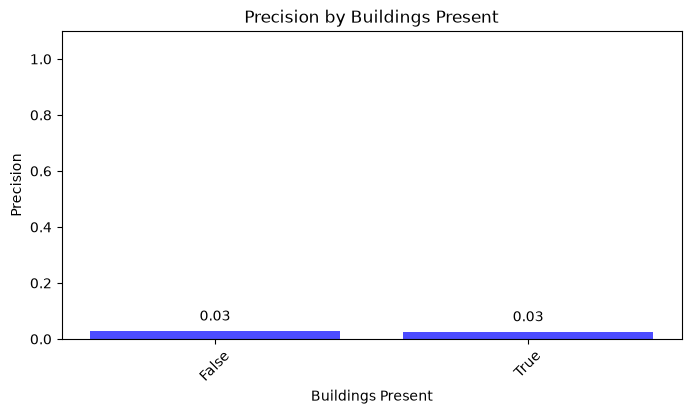

In [81]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='precision', title='Precision by Buildings Present', ylabel='Precision', xlabel='Buildings Present')


### Recall


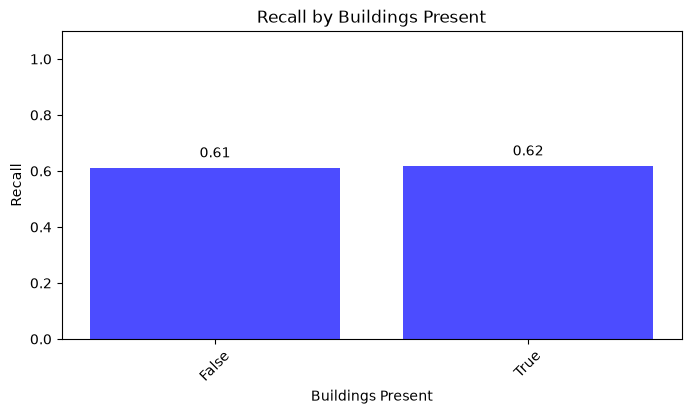

In [82]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='recall', title='Recall by Buildings Present', ylabel='Recall', xlabel='Buildings Present')


### Hit Rate


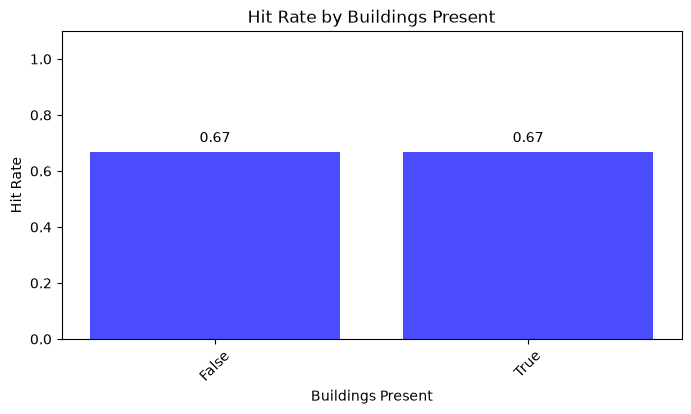

In [83]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='hit_rate', title='Hit Rate by Buildings Present', ylabel='Hit Rate', xlabel='Buildings Present')


### Diversity


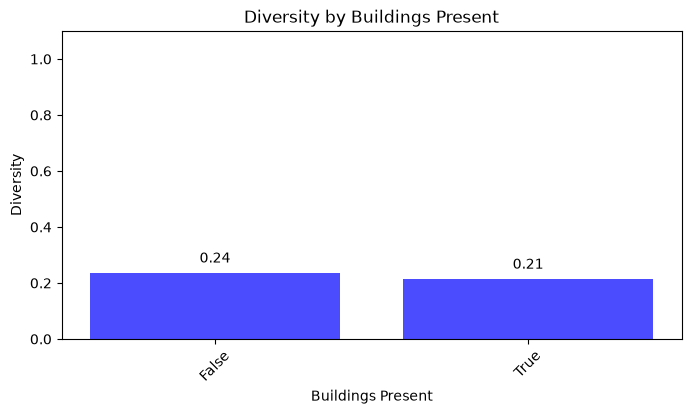

In [84]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='diversity', title='Diversity by Buildings Present', ylabel='Diversity', xlabel='Buildings Present')


### NDCG


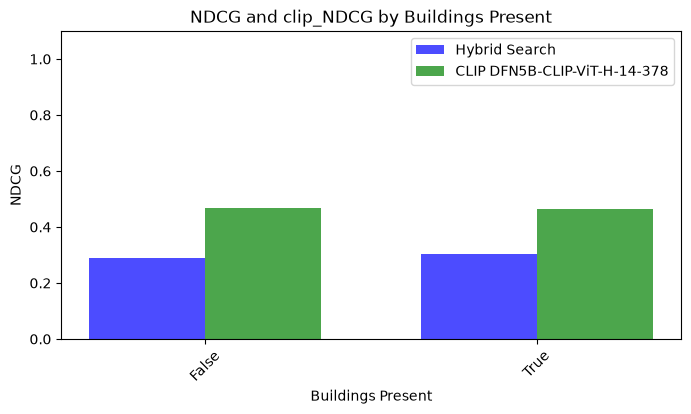

In [85]:
plot_rank_comparison(buildings_present_metrics, x_column='buildings_present', title='NDCG and clip_NDCG by Buildings Present', xlabel='Buildings Present')


### MRR


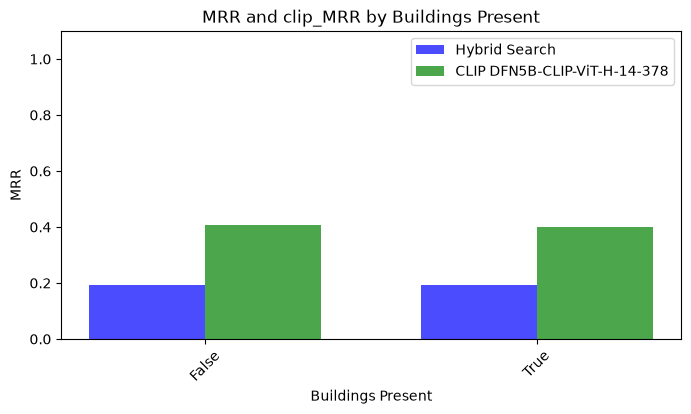

In [86]:
plot_rank_comparison(buildings_present_metrics, x_column='buildings_present', title='MRR and clip_MRR by Buildings Present', xlabel='Buildings Present', metric="MRR")


## Metrics based on Vehicle Present

Now, we will evaluate queries based on **Vehicle Present** (true vs false).


In [87]:
# Group by vehicle_present and calculate the sum/mean of each metric
vehicle_present_metrics = df.groupby('vehicle_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

vehicle_present_metrics['vehicle_present'] = vehicle_present_metrics['vehicle_present'].map({True: 'True', False: 'False'})


#rename columns
vehicle_present_metrics = vehicle_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
vehicle_present_metrics = vehicle_present_metrics.sort_values('vehicle_present')

vehicle_present_metrics


,vehicle_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2850,89,2761,79,2771,0.031228,0.027719,0.598684,0.649123,0.286583,0.452435,0.189759,0.391256,0.225594
1,True,150,7,143,6,144,0.046667,0.040000,0.916667,1.000000,0.452200,0.747856,0.256944,0.666667,0.287969


### Accuracy


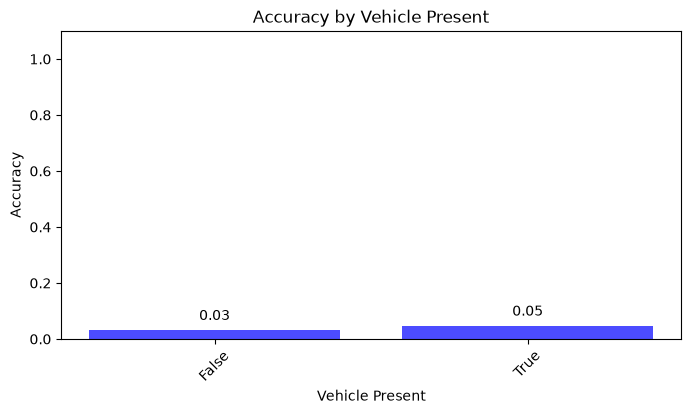

In [88]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='accuracy', title='Accuracy by Vehicle Present', ylabel='Accuracy', xlabel='Vehicle Present')


### Precision


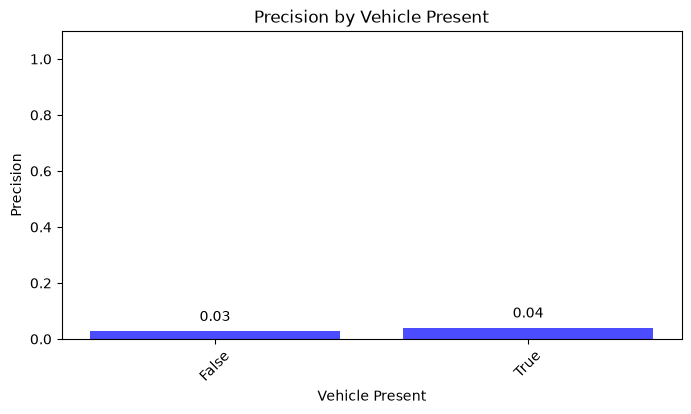

In [89]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='precision', title='Precision by Vehicle Present', ylabel='Precision', xlabel='Vehicle Present')


### Recall


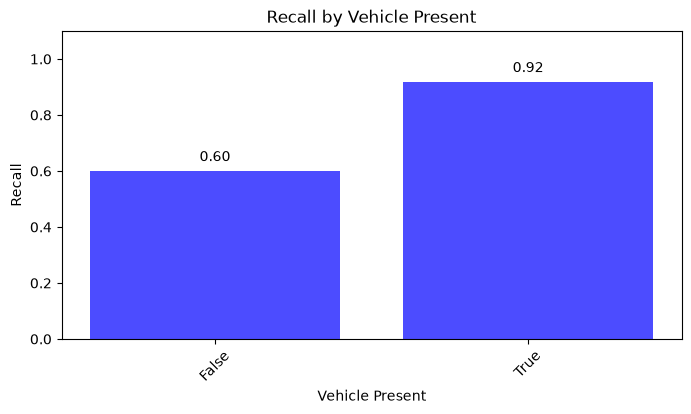

In [90]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='recall', title='Recall by Vehicle Present', ylabel='Recall', xlabel='Vehicle Present')


### Hit Rate


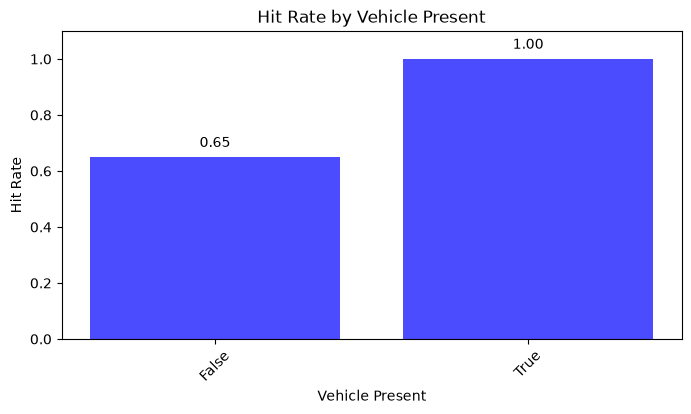

In [91]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='hit_rate', title='Hit Rate by Vehicle Present', ylabel='Hit Rate', xlabel='Vehicle Present')


### Diversity


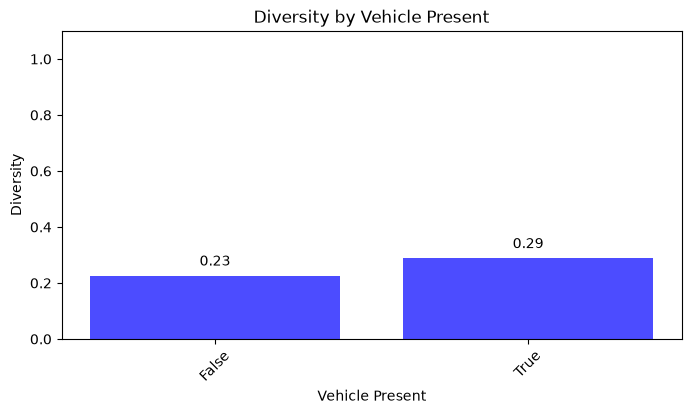

In [92]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='diversity', title='Diversity by Vehicle Present', ylabel='Diversity', xlabel='Vehicle Present')


### NDCG


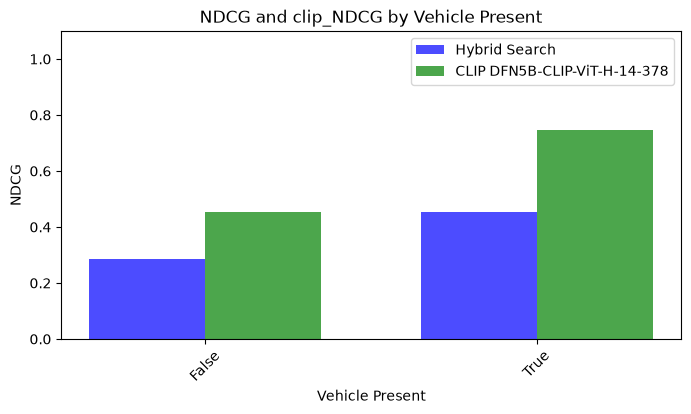

In [93]:
plot_rank_comparison(vehicle_present_metrics, x_column='vehicle_present', title='NDCG and clip_NDCG by Vehicle Present', xlabel='Vehicle Present')


### MRR


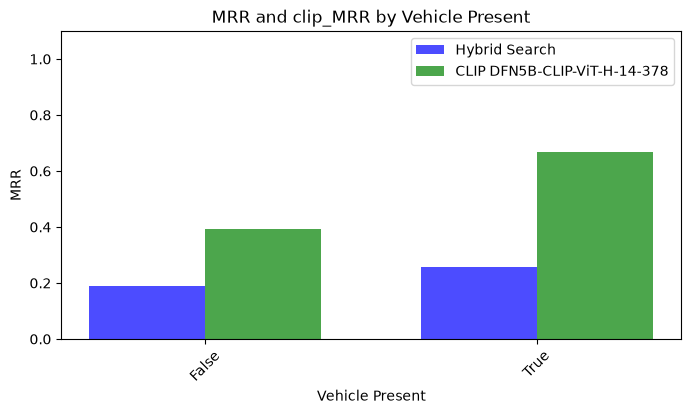

In [94]:
plot_rank_comparison(vehicle_present_metrics, x_column='vehicle_present', title='MRR and clip_MRR by Vehicle Present', xlabel='Vehicle Present', metric="MRR")


## Metrics based on Person Present

Now, we will evaluate queries based on **Person Present** (true vs false).


In [95]:
# Group by person_present and calculate the sum/mean of each metric
person_present_metrics = df.groupby('person_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

person_present_metrics['person_present'] = person_present_metrics['person_present'].map({True: 'True', False: 'False'})

#rename columns
person_present_metrics = person_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
person_present_metrics = person_present_metrics.sort_values('person_present')

person_present_metrics


,person_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,3000,96,2904,85,2915,0.032,0.028333,0.614583,0.666667,0.294864,0.467206,0.193118,0.405026,0.228713


### Accuracy


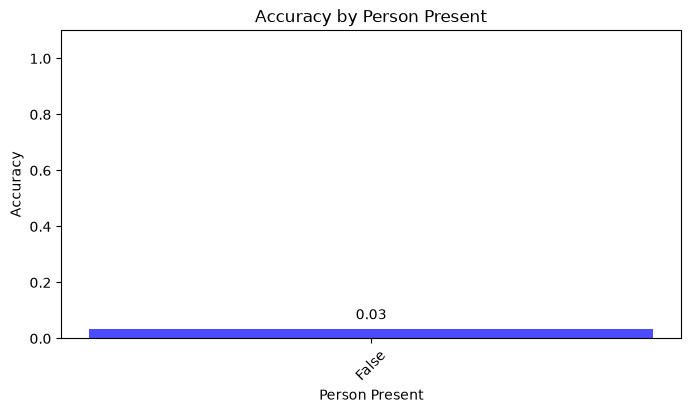

In [96]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='accuracy', title='Accuracy by Person Present', ylabel='Accuracy', xlabel='Person Present')


### Precision


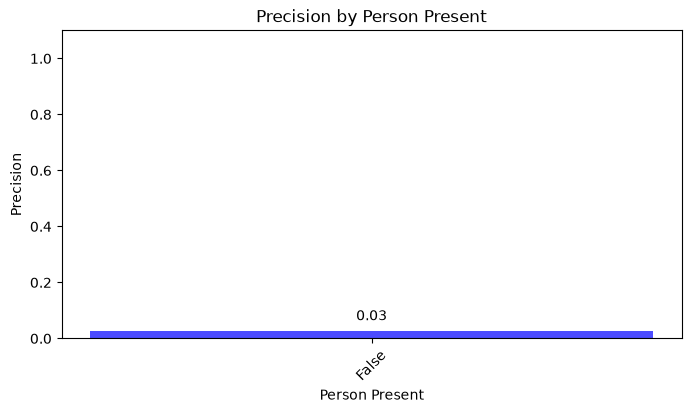

In [97]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='precision', title='Precision by Person Present', ylabel='Precision', xlabel='Person Present')


### Recall


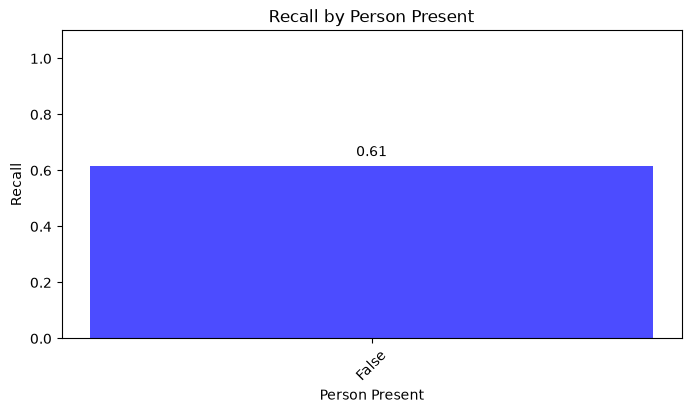

In [98]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='recall', title='Recall by Person Present', ylabel='Recall', xlabel='Person Present')


### Hit Rate


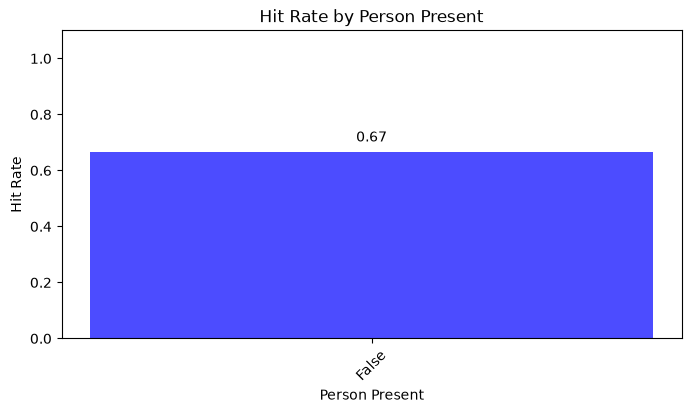

In [99]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='hit_rate', title='Hit Rate by Person Present', ylabel='Hit Rate', xlabel='Person Present')


### Diversity


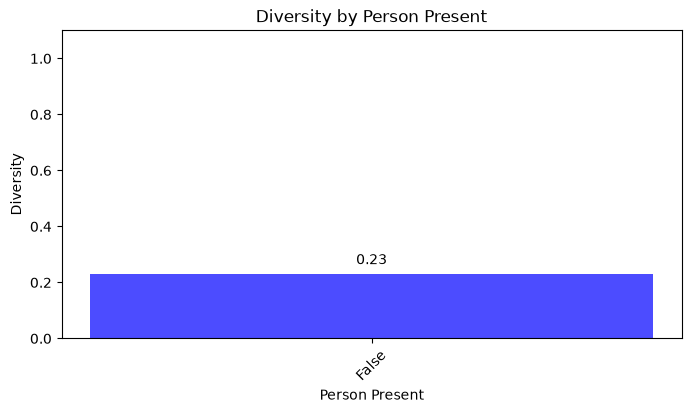

In [100]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='diversity', title='Diversity by Person Present', ylabel='Diversity', xlabel='Person Present')


### NDCG


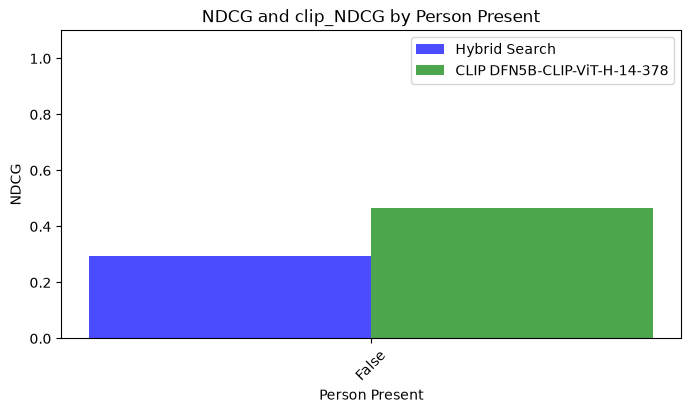

In [101]:
plot_rank_comparison(person_present_metrics, x_column='person_present', title='NDCG and clip_NDCG by Person Present', xlabel='Person Present')


### MRR


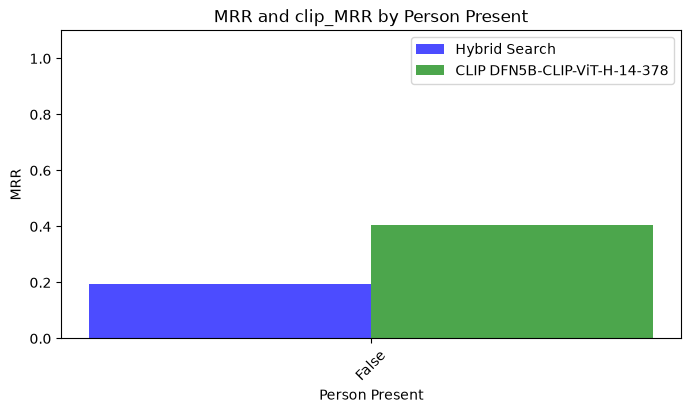

In [102]:
plot_rank_comparison(person_present_metrics, x_column='person_present', title='MRR and clip_MRR by Person Present', xlabel='Person Present', metric="MRR")


## Metrics based on Animal Present

Now, we will evaluate queries based on **Animal Present** (true vs false).


In [103]:
# Group by animal_present and calculate the sum/mean of each metric
animal_present_metrics = df.groupby('animal_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

animal_present_metrics['animal_present'] = animal_present_metrics['animal_present'].map({True: 'True', False: 'False'})

#rename columns
animal_present_metrics = animal_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
animal_present_metrics = animal_present_metrics.sort_values('animal_present')

animal_present_metrics


,animal_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,3000,96,2904,85,2915,0.032,0.028333,0.614583,0.666667,0.294864,0.467206,0.193118,0.405026,0.228713


### Accuracy


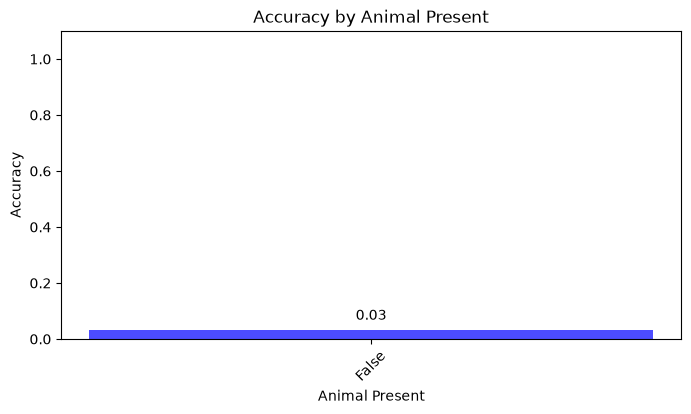

In [104]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='accuracy', title='Accuracy by Animal Present', ylabel='Accuracy', xlabel='Animal Present')


### Precision


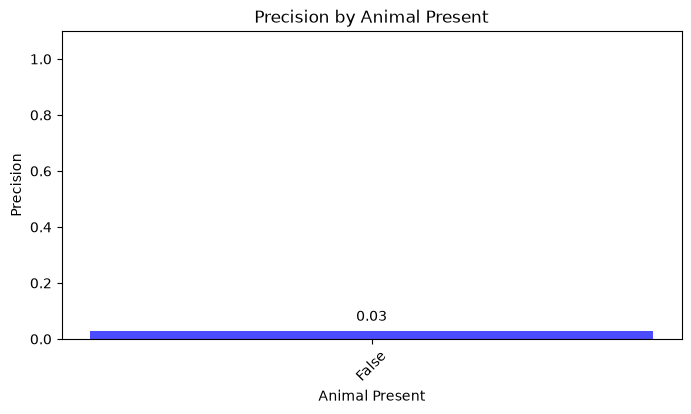

In [105]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='precision', title='Precision by Animal Present', ylabel='Precision', xlabel='Animal Present')


### Recall


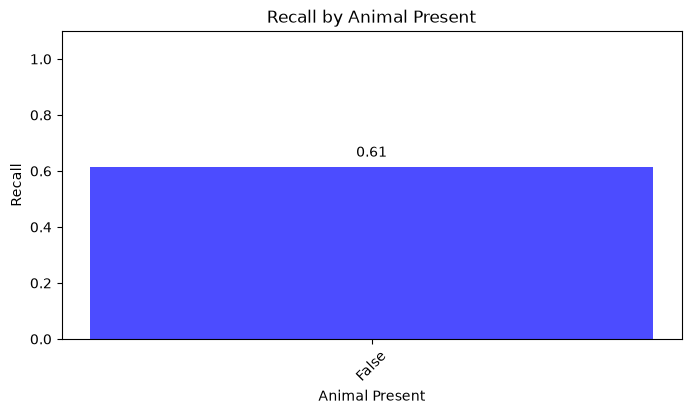

In [106]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='recall', title='Recall by Animal Present', ylabel='Recall', xlabel='Animal Present')


### Hit Rate


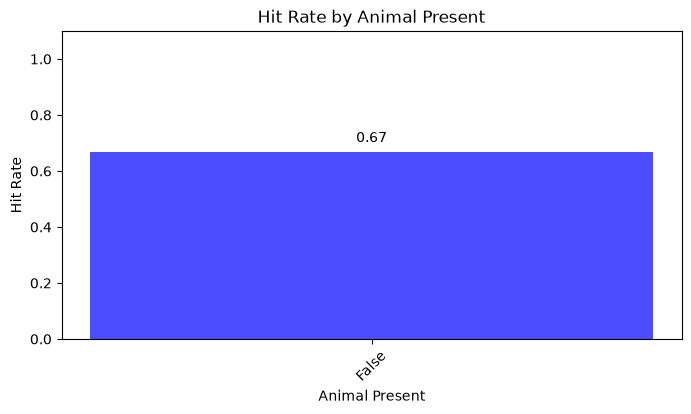

In [107]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='hit_rate', title='Hit Rate by Animal Present', ylabel='Hit Rate', xlabel='Animal Present')


### Diversity


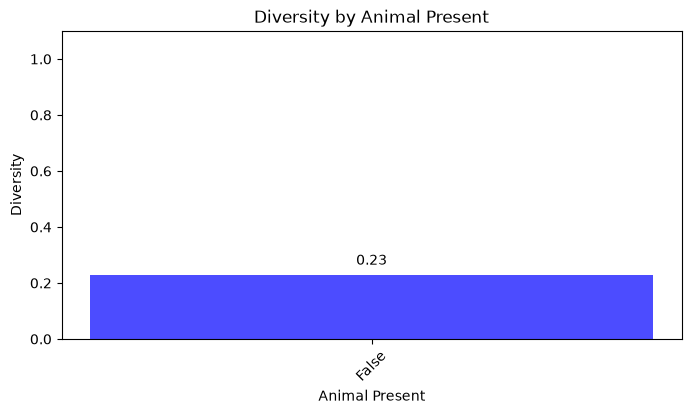

In [108]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='diversity', title='Diversity by Animal Present', ylabel='Diversity', xlabel='Animal Present')


### NDCG


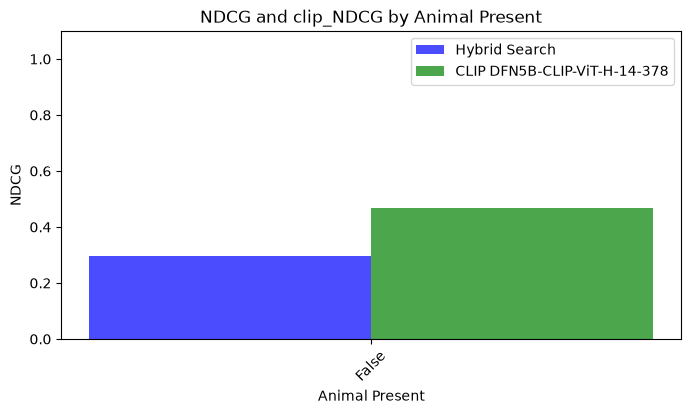

In [109]:
plot_rank_comparison(animal_present_metrics, x_column='animal_present', title='NDCG and clip_NDCG by Animal Present', xlabel='Animal Present')


### MRR


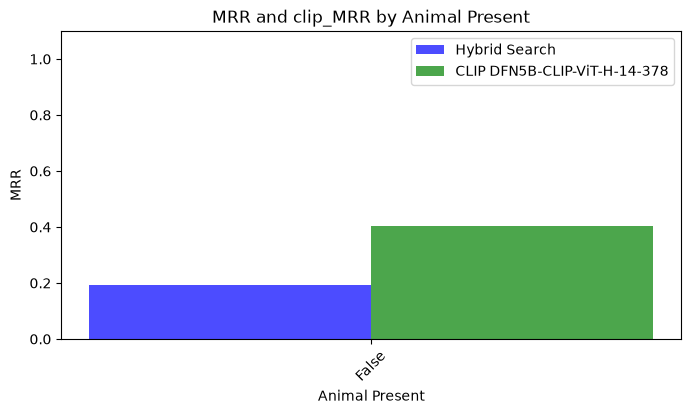

In [110]:
plot_rank_comparison(animal_present_metrics, x_column='animal_present', title='MRR and clip_MRR by Animal Present', xlabel='Animal Present', metric="MRR")


## Metrics based on Night Scene

Now, we will evaluate queries based on **Night Scene** (true vs false).


In [111]:
# Group by night_scene and calculate the sum/mean of each metric
night_scene_metrics = df.groupby('night_scene').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

night_scene_metrics['night_scene'] = night_scene_metrics['night_scene'].map({True: 'True', False: 'False'})

#rename columns
night_scene_metrics = night_scene_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
night_scene_metrics = night_scene_metrics.sort_values('night_scene')

night_scene_metrics


,night_scene,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1975,64,1911,56,1919,0.032405,0.028354,0.602321,0.645570,0.302415,0.486365,0.20645,0.436498,0.217560
1,True,1025,32,993,29,996,0.031220,0.028293,0.638211,0.707317,0.280314,0.430291,0.16743,0.344386,0.250202


### Accuracy


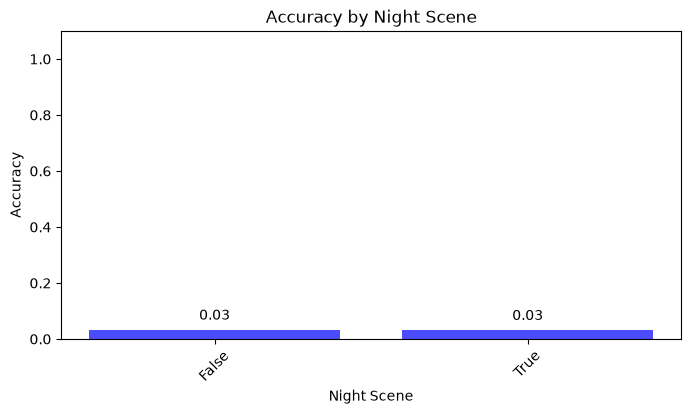

In [112]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='accuracy', title='Accuracy by Night Scene', ylabel='Accuracy', xlabel='Night Scene')


### Precision


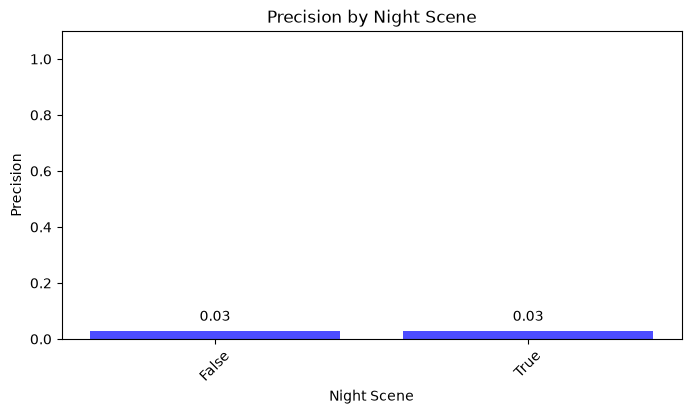

In [113]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='precision', title='Precision by Night Scene', ylabel='Precision', xlabel='Night Scene')


### Recall


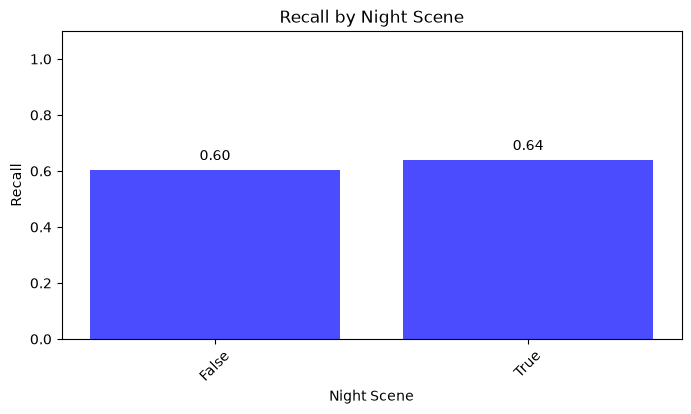

In [114]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='recall', title='Recall by Night Scene', ylabel='Recall', xlabel='Night Scene')


### Hit Rate


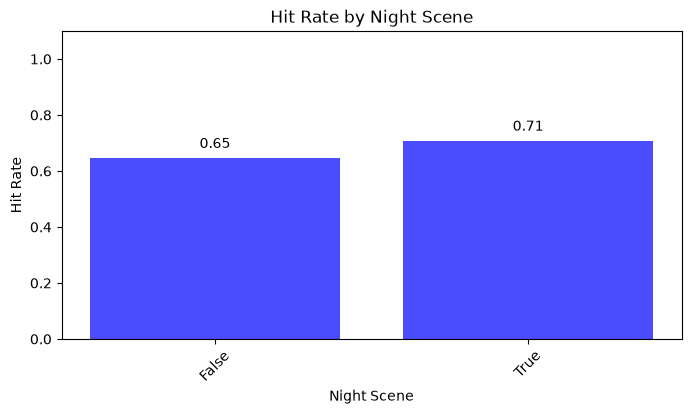

In [115]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='hit_rate', title='Hit Rate by Night Scene', ylabel='Hit Rate', xlabel='Night Scene')


### Diversity


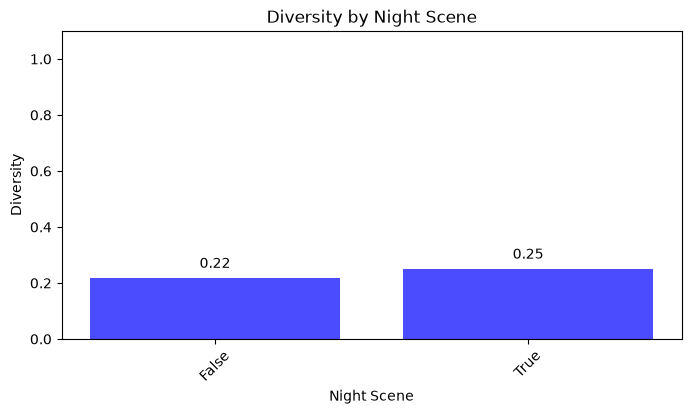

In [116]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='diversity', title='Diversity by Night Scene', ylabel='Diversity', xlabel='Night Scene')


### NDCG


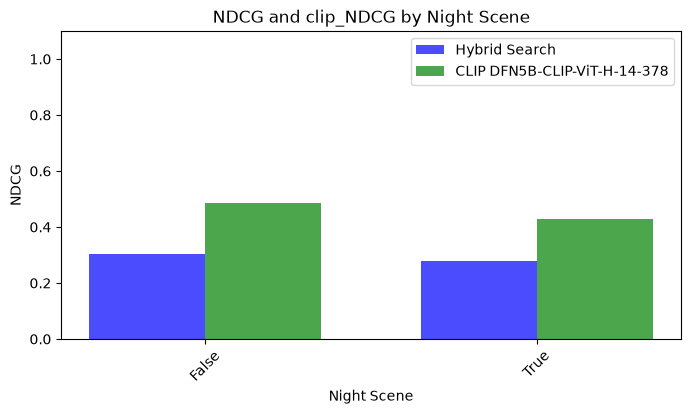

In [117]:
plot_rank_comparison(night_scene_metrics, x_column='night_scene', title='NDCG and clip_NDCG by Night Scene', xlabel='Night Scene')


### MRR


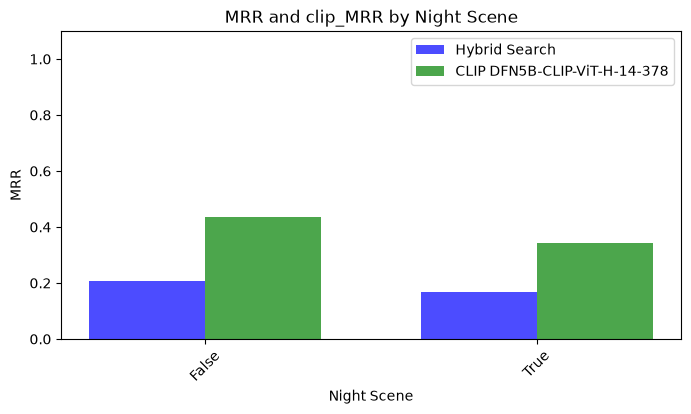

In [118]:
plot_rank_comparison(night_scene_metrics, x_column='night_scene', title='MRR and clip_MRR by Night Scene', xlabel='Night Scene', metric="MRR")


## Metrics based on Precipitation Visible

Now, we will evaluate queries based on **Precipitation Visible** (true vs false).


In [119]:
# Group by precipitation_visible and calculate the sum/mean of each metric
precipitation_visible_metrics = df.groupby('precipitation_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

precipitation_visible_metrics['precipitation_visible'] = precipitation_visible_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
precipitation_visible_metrics = precipitation_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
precipitation_visible_metrics = precipitation_visible_metrics.sort_values('precipitation_visible')

precipitation_visible_metrics


,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2900,94,2806,83,2817,0.032414,0.028621,0.618534,0.672414,0.300003,0.469257,0.197971,0.406062,0.230470
1,True,100,2,98,2,98,0.020000,0.020000,0.500000,0.500000,0.145833,0.407732,0.052381,0.375000,0.177756


### Accuracy


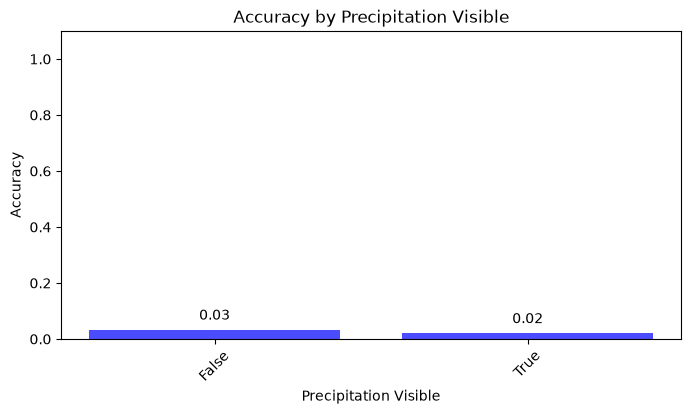

In [120]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='accuracy', title='Accuracy by Precipitation Visible', ylabel='Accuracy', xlabel='Precipitation Visible')


### Precision


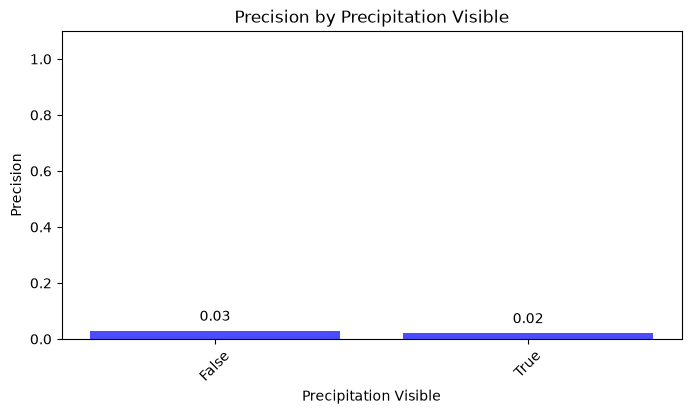

In [121]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='precision', title='Precision by Precipitation Visible', ylabel='Precision', xlabel='Precipitation Visible')


### Recall


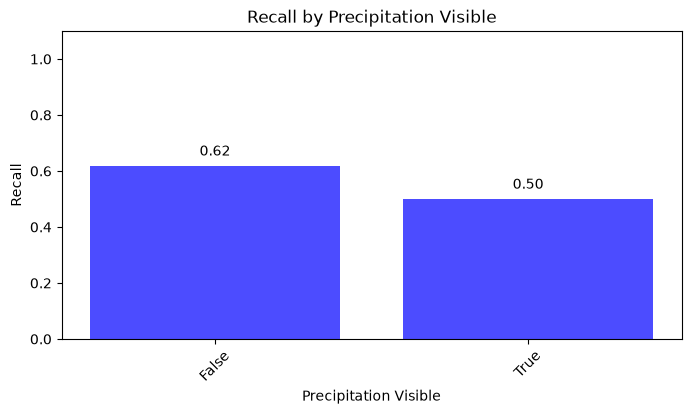

In [122]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='recall', title='Recall by Precipitation Visible', ylabel='Recall', xlabel='Precipitation Visible')


### Hit Rate


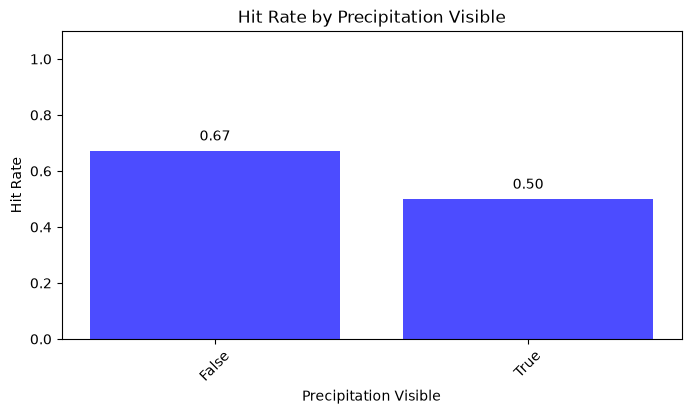

In [123]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='hit_rate', title='Hit Rate by Precipitation Visible', ylabel='Hit Rate', xlabel='Precipitation Visible')


### Diversity


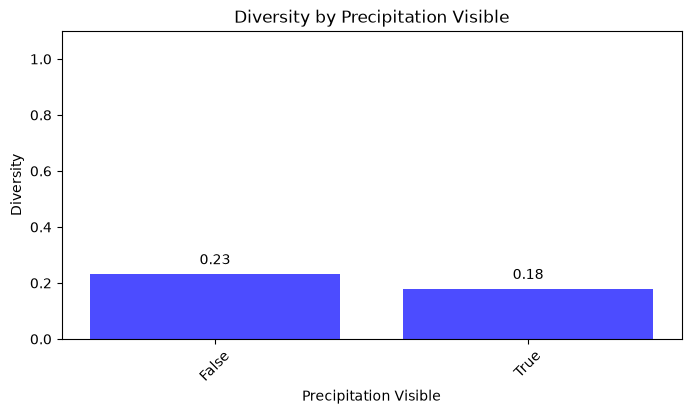

In [124]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='diversity', title='Diversity by Precipitation Visible', ylabel='Diversity', xlabel='Precipitation Visible')


### NDCG


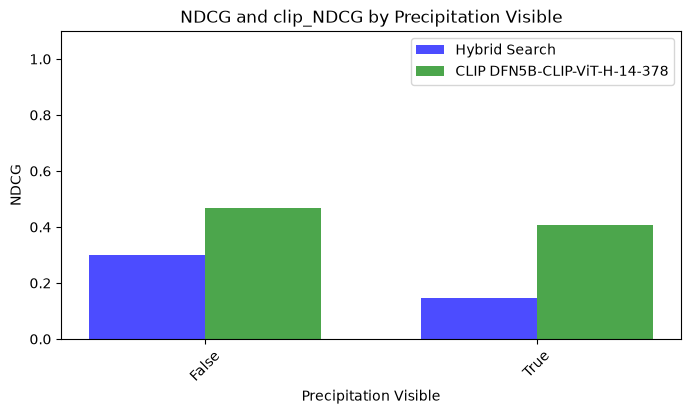

In [125]:
plot_rank_comparison(precipitation_visible_metrics, x_column='precipitation_visible', title='NDCG and clip_NDCG by Precipitation Visible', xlabel='Precipitation Visible')


### MRR


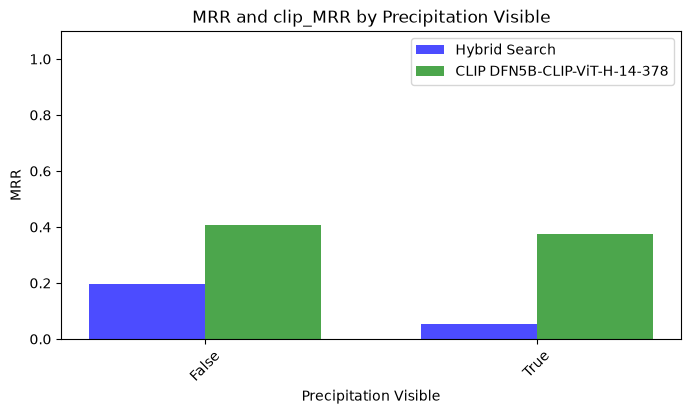

In [126]:
plot_rank_comparison(precipitation_visible_metrics, x_column='precipitation_visible', title='MRR and clip_MRR by Precipitation Visible', xlabel='Precipitation Visible', metric="MRR")


## Metrics based on Multiple Objects

Now, we will evaluate queries based on **Multiple Objects** (true vs false).


In [127]:
# Group by multiple_objects and calculate the sum/mean of each metric
multiple_objects_metrics = df.groupby('multiple_objects').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

multiple_objects_metrics['multiple_objects'] = multiple_objects_metrics['multiple_objects'].map({True: 'True', False: 'False'})

#rename columns
multiple_objects_metrics = multiple_objects_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
multiple_objects_metrics = multiple_objects_metrics.sort_values('multiple_objects')

multiple_objects_metrics


,multiple_objects,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,250,8,242,7,243,0.032,0.028000,0.633333,0.700000,0.169339,0.338385,0.042429,0.231508,0.295149
1,True,2750,88,2662,78,2672,0.032,0.028364,0.612879,0.663636,0.306275,0.478917,0.206817,0.420801,0.222673


### Accuracy


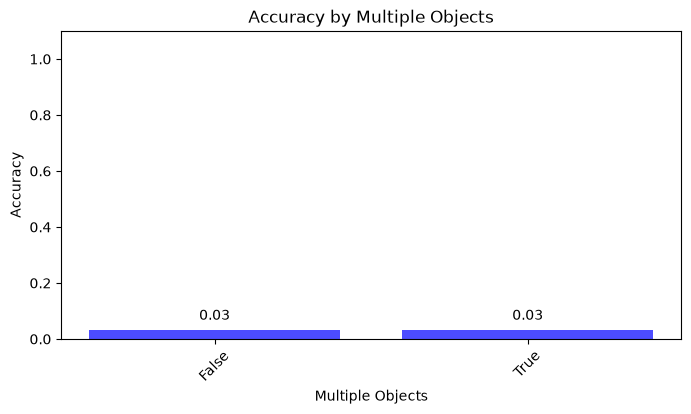

In [128]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='accuracy', title='Accuracy by Multiple Objects', ylabel='Accuracy', xlabel='Multiple Objects')


### Precision


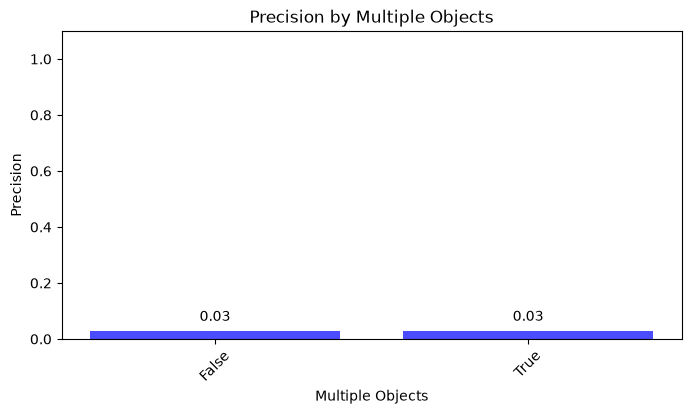

In [129]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='precision', title='Precision by Multiple Objects', ylabel='Precision', xlabel='Multiple Objects')


### Recall


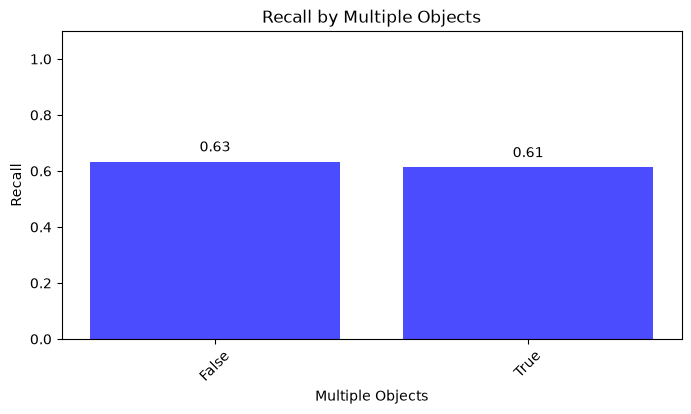

In [130]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='recall', title='Recall by Multiple Objects', ylabel='Recall', xlabel='Multiple Objects')


### Hit Rate


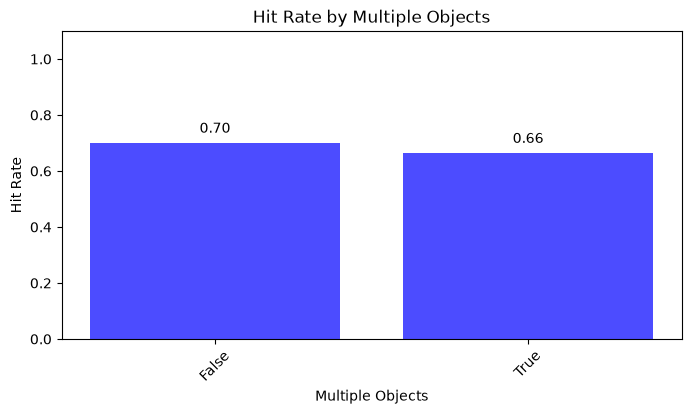

In [131]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='hit_rate', title='Hit Rate by Multiple Objects', ylabel='Hit Rate', xlabel='Multiple Objects')


### Diversity


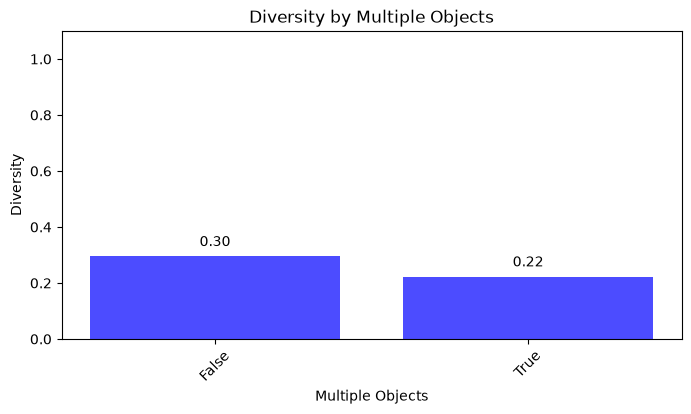

In [132]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='diversity', title='Diversity by Multiple Objects', ylabel='Diversity', xlabel='Multiple Objects')


### NDCG


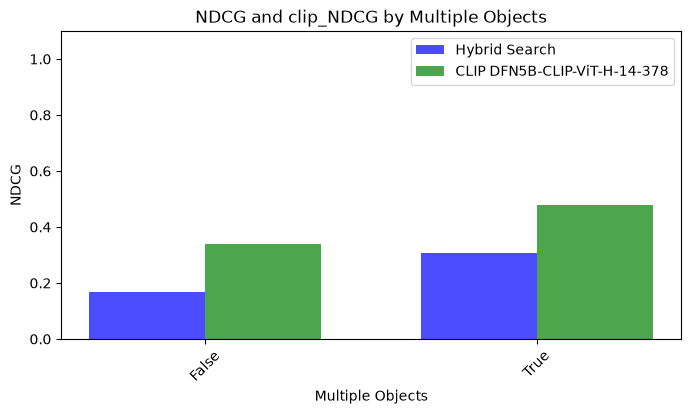

In [133]:
plot_rank_comparison(multiple_objects_metrics, x_column='multiple_objects', title='NDCG and clip_NDCG by Multiple Objects', xlabel='Multiple Objects')


### MRR


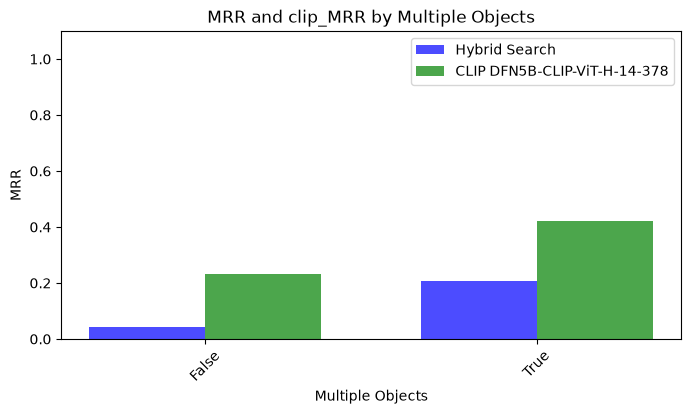

In [134]:
plot_rank_comparison(multiple_objects_metrics, x_column='multiple_objects', title='MRR and clip_MRR by Multiple Objects', xlabel='Multiple Objects', metric="MRR")


## Metrics based on Viewpoint & Precipitation Visible

Here we will group by Precipitation Visible and Viewpoint and calculate the sum/mean of each metric to see how the system performs under different Precipitation Visible and Viewpoint conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [135]:
# Group
view_preci_metrics = df.groupby(['viewpoint', 'precipitation_visible']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()
view_preci_metrics['precipitation_visible'] = view_preci_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
view_preci_metrics = view_preci_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = view_preci_metrics
x_column = 'viewpoint'
group_column = 'precipitation_visible'
title = 'Viewpoint & Precipitation Visible'
colors = {
    "True": "green",
    "False": "red",
}

metrics

,viewpoint,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,duo_view,False,50,1,49,1,49,0.020000,0.020000,0.500000,0.500000,0.150515,0.250000,0.055556,0.166667,0.198443
1,fisheye_sky,False,625,23,602,19,606,0.036800,0.030400,0.613333,0.680000,0.238944,0.434921,0.117910,0.352190,0.180234
2,fisheye_sky,True,75,1,74,1,74,0.013333,0.013333,0.333333,0.333333,0.111111,0.333333,0.047619,0.333333,0.157510
3,ground_horizontal,False,1900,61,1839,54,1846,0.032105,0.028421,0.628289,0.671053,0.317763,0.486769,0.220225,0.431140,0.243127
4,ground_horizontal,True,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.250000,0.630930,0.066667,0.500000,0.238492
5,ground_upward,False,150,4,146,4,146,0.026667,0.026667,0.666667,0.666667,0.354663,0.488660,0.272398,0.435185,0.264884
6,oblique,False,125,3,122,3,122,0.024000,0.024000,0.466667,0.600000,0.357813,0.500000,0.286667,0.466667,0.222254
7,unknown,False,50,2,48,2,48,0.040000,0.040000,0.666667,1.000000,0.229338,0.317182,0.050505,0.126984,0.326765


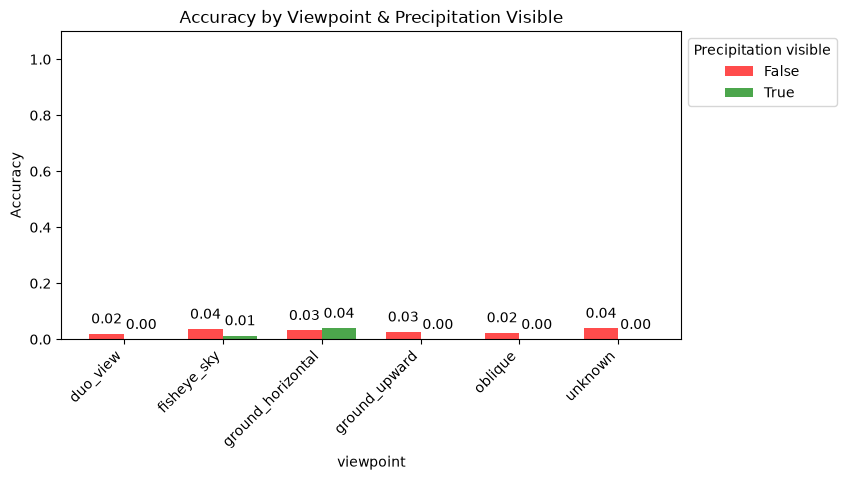

In [136]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='accuracy', 
    color_map=colors, 
    ylabel="Accuracy", 
    xlabel=x_column, 
    title=f"Accuracy by {title}",
)

### Precision

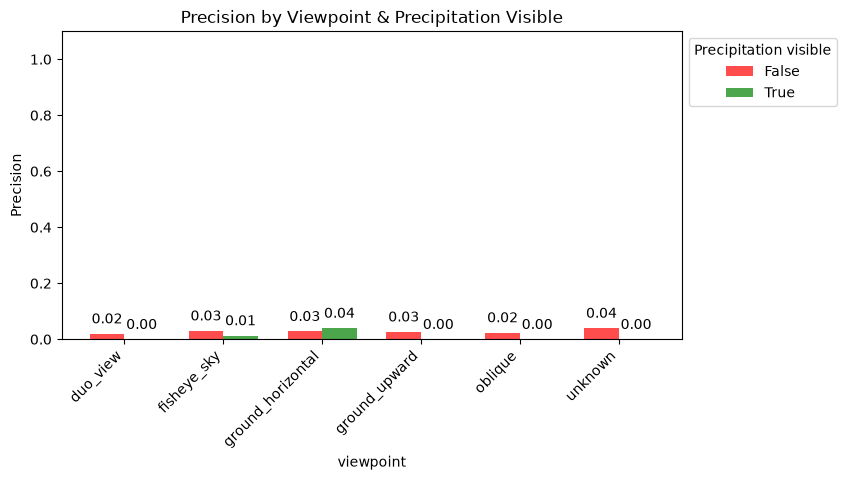

In [137]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='precision', 
    color_map=colors, 
    ylabel="Precision", 
    xlabel=x_column, 
    title=f"Precision by {title}",
)

### Recall

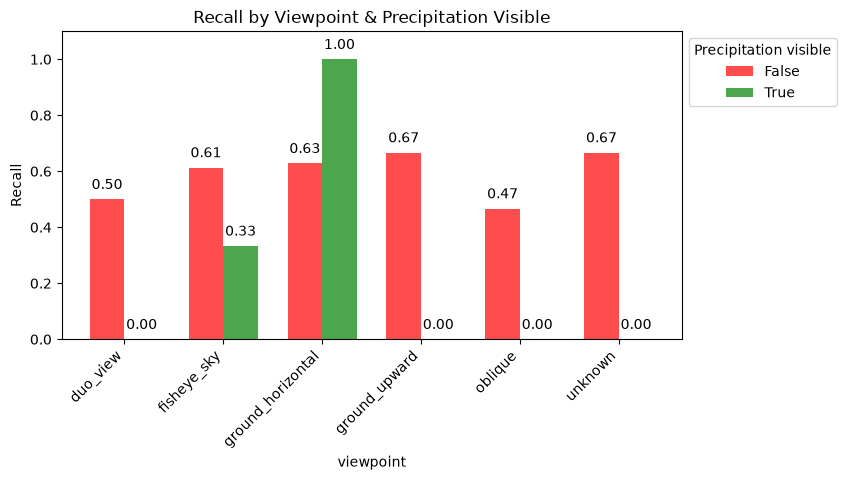

In [138]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='recall', 
    color_map=colors,
    ylabel="Recall", 
    xlabel=x_column, 
    title=f"Recall by {title}",
)


### Hit Rate

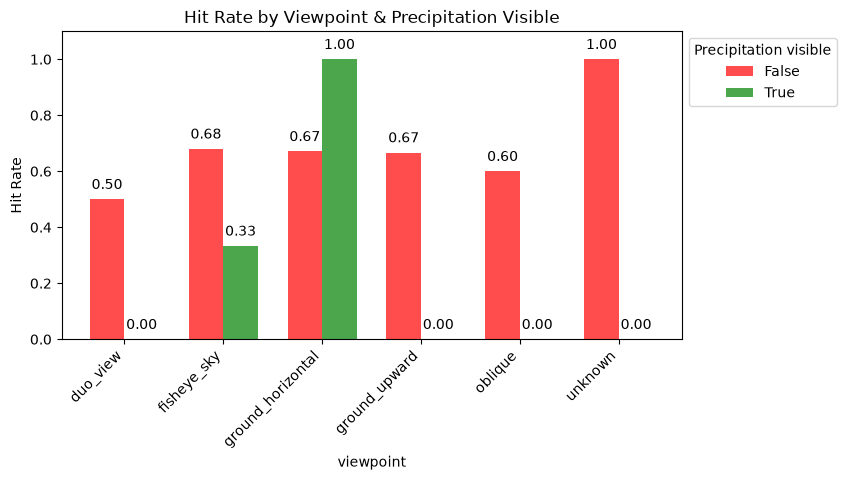

In [139]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='hit_rate', 
    color_map=colors,
    ylabel="Hit Rate", 
    xlabel=x_column, 
    title=f"Hit Rate by {title}",
)

### Diversity

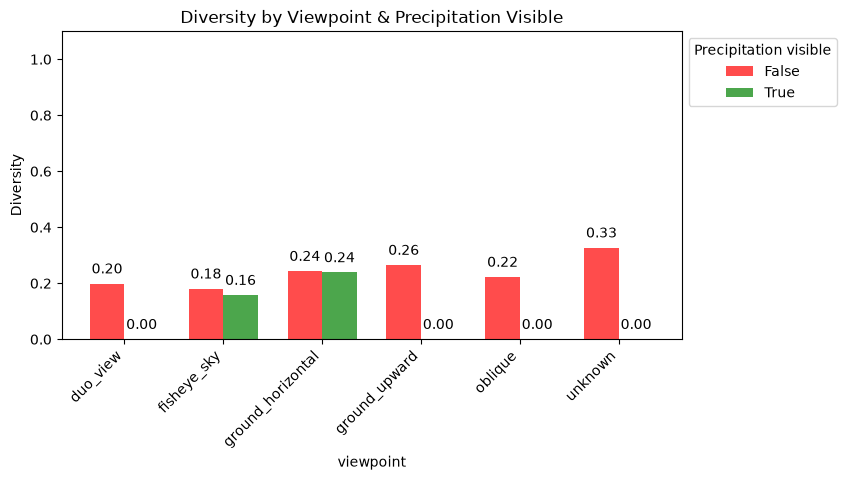

In [140]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='diversity', 
    color_map=colors,
    ylabel="Diversity", 
    xlabel=x_column, 
    title=f"Diversity by {title}",
)

### NDCG

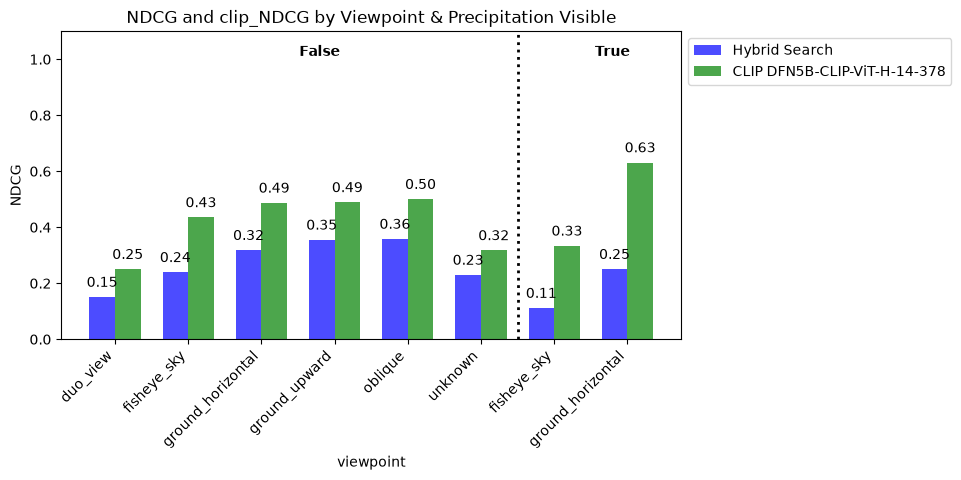

In [141]:
# Sort by group_column so group dividers and labels are correct
_ndcg_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column=x_column,
    group_column=group_column,
    title=f"NDCG and clip_NDCG by {title}",
    xlabel=x_column,
)


### MRR

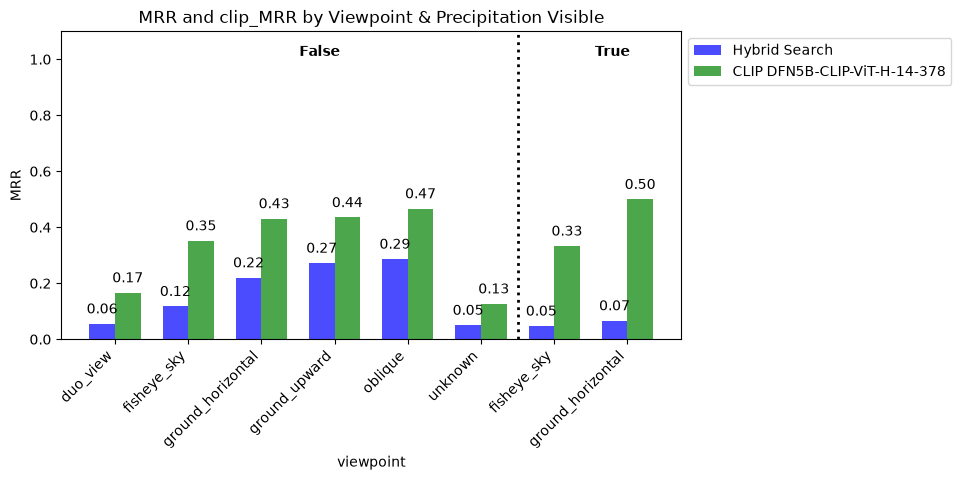

In [142]:
_mrr_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(_mrr_df, x_column=x_column, group_column=group_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Insights & Conclusion

**System Difference**

* **v12:** Weaviate hybrid search over **one fused CLIP index** (caption + image embeddings combined into a single `clip` vector), with the Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. CLIP inference had **no Triton dynamic batching**.
* **v13:**
  * **Weaviate → Milvus** as the vector database.
  * **Weaviate reranker → Apple CLIP DFN** (`DFN5B-CLIP-ViT-H-14-378`): query text vs stored `image_vector`s.
  * **One fused index → dual indexing**: separate `caption_vector` and `image_vector` fields, blended at query time (`clip_alpha=0.7`).
  * **No Triton batching → Triton dynamic batching** for CLIP (and Gemma when served on Triton), so concurrent embedding/caption requests coalesce into larger GPU batches.
* **v14:**
  * v13 additions plus LLM Image Byte Limiting - Caption images are preprocessed before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).

---

**Overall Metrics Comparison**

Byte limiting is the v14 increment on the v13 stack. **Δ (v13 − v12)** is the Milvus / dual-index / CLIP DFN move; **Δ (v14 − v13)** is caption image byte limiting; **Δ (v14 − v12)** is the net vs the Weaviate baseline.

| Metric                   | v12 | v13 | v14 | Δ (v13 − v12) | Δ (v14 − v13) | Δ (v14 − v12) |
| ------------------------ | --- | --- | --- | ------------- | ------------- | ------------- |
| **Total Images**         | 3,000 | 3,000 | 3,000 | 0 | 0 | 0 |
| **Correctly Returned**   | 79 | 103 | 96 | +24 | −7 | +17 |
| **Incorrectly Returned** | 2,921 | 2,897 | 2,904 | −24 | +7 | −17 |
| **Relevant Images**      | 68 | 79 | 85 | +11 | +6 | +17 |
| **Accuracy**             | 0.0263 | 0.0343 | 0.0320 | +0.0080 | −0.0023 | +0.0057 |
| **Precision**            | 0.0227 | 0.0263 | 0.0283 | +0.0036 | +0.0020 | +0.0056 |
| **Recall**               | 0.5033 | 0.5600 | 0.6146 | +0.0567 | +0.0546 | +0.1113 |
| **Hit Rate**             | 0.5417 | 0.6167 | 0.6667 | +0.0750 | +0.0500 | +0.1250 |
| **Diversity**            | 0.2070 | 0.2222 | 0.2287 | +0.0152 | +0.0065 | +0.0217 |
| **NDCG** | 0.2111 | 0.2957 | 0.2949 | +0.0845 | −0.0008 | +0.0838 |
| **clip_NDCG** | 0.4274 | 0.4635 | 0.4672 | +0.0361 | +0.0037 | +0.0398 |
| **MRR** | 0.1218 | 0.2068 | 0.1931 | +0.0851 | −0.0137 | +0.0713 |
| **clip_MRR** | 0.3915 | 0.4146 | 0.4050 | +0.0231 | −0.0096 | +0.0135 |
| **DLQ entries**          | — | 896 | 0 | — | −896 | — |

---

**Interpretation**

**Caption reliability is solved.** v13 had **896** DLQ rows, all **`inserted_degraded`** (empty caption from the provider after 6 attempts; dataset-`summary` fallback; 714 unique images; 0 recovered, 0 abandoned). v14 has **zero** DLQ rows: every image got a real Gemma caption under the 12 MiB / 6144-side cap.

**Labeled retrieval continues up.** Versus v13, **hit rate +5.0 pp** (74/120 → 80/120), **relevant images +6**, **recall +0.055**, **precision +0.002**. **Correctly returned** dips (−7) and **accuracy** with it (−0.002); coverage of labeled-relevant items still improved. Versus v12 this is a clear net win (hit rate **54.2% → 66.7%**). Same IR sign as Commonobjects, opposite of Firebench/Cloudbench.

**Production first-hit ranking eases; CLIP-oracle lists keep climbing.** **NDCG** is flat vs v13. **MRR 0.21 → 0.19** (still well above v12 0.12). **clip_NDCG / clip_MRR** are essentially flat (0.46 → 0.47 / 0.41 → 0.41). The gap to the CLIP oracle **stays large** (MRR **0.19 vs 0.41**): more of the right images enter k=25, but CLIP DFN still cannot put a specific VSN first. Sage queries mix visual content with **node metadata** (vsn, zone, job, camera).

**Diversity** ticks up again (+0.007).

---

**Insights**

- **This is the caption-yield win v13 predicted.** v13 said Sage BM25 is supposed to carry vsn/job/camera tokens, and 896 summary-fallback captions were starving that leg. Real Gemma captions (and overlay text the prompt asks to extract) restore `search_text` / `caption_vector`. Image vectors were never byte-capped; the v14 increment is the caption/BM25 path plus a complete index.
- **Night and shield recover; core stays put.** Night hit rate was stuck at **0.46** in v12 and v13; v14 jumps to **0.71**. Shield **0.57 → 0.77** (above v12 0.73). Core stays **0.61**. Day eases slightly (**0.68 → 0.65**). Empty/summary captions were especially useless on dark IR/night frames; capped Gemma still says “night, railing, IR.”
- **Hit churn favors v14:** 20 queries gained a hit, 14 lost one. Gains concentrate on **night platforms / starry skies / IR** (many V041 left_camera) and **shield fisheye**. Losses concentrate on **mobotix split RGB/thermal and foggy W097** scenes (mobotix hit **0.92 → 0.62**; fog_or_haze **0.56 → 0.22**) — the Firebench-like cost of downscaling thermal/fog frames — plus a few daytime tower-platform duplicates.
- **Fisheye / top_camera keep climbing** (fisheye **0.54 → 0.64**; top_camera **0.44 → 0.56**). Sky stills on Sage nodes are not 6k webcams in the Firebench sense; the side cap is enough for Gemma to name pole, sun, and fisheye.
- **MRR vs clip_MRR is still the metadata hole.** Byte limiting improved candidate generation (clip_NDCG up with hit rate) without teaching the image reranker node IDs. Isolate byte limiting with **v14 vs v13**. Do not read v14 vs v12 as “byte limiting vs Weaviate.”

---

**Conclusion**

On Sagebench, **v14 is the right production default on top of v13:** DLQ goes **896 → 0**, hit rate / recall / relevant counts rise again, and CLIP-oracle list quality improves. **MRR stays far behind clip_MRR** because queries are metadata-heavy. Keep byte limiting. Next IR work is still **structured Sage fields in BM25/`search_text` (or a VSN/zone filter)** so first-hit ranking can use node identity, not rolling back Milvus, CLIP DFN, or the size cap.
